## Exp 1

### Raw - Analysis and EDA

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# 0. Imports
# ─────────────────────────────────────────────────────────────────────────────

# Core data libraries
import numpy as np
import pandas as pd

# Model building & preprocessing
from sklearn.compose      import ColumnTransformer
from sklearn.pipeline     import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_validate,
    RandomizedSearchCV
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble     import RandomForestRegressor, GradientBoostingRegressor

# Metrics / evaluation
from sklearn.metrics      import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Explainability
import shap

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical distributions for hyperparameter search
from scipy.stats          import randint, uniform

# Misc
import pprint


/opt/anaconda3/envs/thesis/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
df_raw = pd.read_csv('data/exp1_raw.csv')
df_agg = pd.read_csv('data/exp1_agg.csv')

# 2. Quick overview
print('raw info: ',df_raw.info())
print('agg info: ',df_agg.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115887 entries, 0 to 115886
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    115887 non-null  int64  
 1   system_d              115887 non-null  float64
 2   dependency            115887 non-null  object 
 3   counterbalance_block  115887 non-null  float64
 4   Block                 115887 non-null  int64  
 5   Alert_System          115887 non-null  int64  
 6   Trial                 115887 non-null  int64  
 7   Event Type            115887 non-null  object 
 8   Alarm Output          115887 non-null  object 
 9   Stimulus              115887 non-null  float64
 10  Score                 115887 non-null  int64  
 11  User Action           115887 non-null  object 
 12  Classification Time   115887 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 11.5+ MB
raw info:  None
<class 'pandas.core.frame.Data

In [3]:
print('agg head: ')
df_agg.head()

agg head: 


,id,block,system_d,dependency,How much did the automation help you in the task?,How good was the automation in distinguishing between blue and orange Vibranium strains?
0,1,2,1.0,Independent,3,1
1,1,5,1.0,Independent,6,2
2,4,2,1.0,Low,5,4
3,4,3,1.0,Low,4,2
4,5,2,1.5,High,5,7


In [4]:
agg = df_agg.rename(columns={
    'How much did the automation help you in the task?': 'help_task_score',
    'How good was the automation in distinguishing between blue and orange Vibranium strains?': 'distinguishing_score'
})
# Create a new column for average score
agg['avg_score'] = agg[['help_task_score', 'distinguishing_score']].mean(axis=1)

agg.head()

,id,block,system_d,dependency,help_task_score,distinguishing_score,avg_score
0,1,2,1.0,Independent,3,1,2.0
1,1,5,1.0,Independent,6,2,4.0
2,4,2,1.0,Low,5,4,4.5
3,4,3,1.0,Low,4,2,3.0
4,5,2,1.5,High,5,7,6.0


In [5]:
print('raw :')
df_raw.head(5)

raw :


,ID,system_d,dependency,counterbalance_block,Block,Alert_System,Trial,Event Type,Alarm Output,Stimulus,Score,User Action,Classification Time
0,1,1.0,Independent,4.0,1,0,1,S,No Alarm,8.23,33,S,2.568716
1,1,1.0,Independent,4.0,1,0,2,N,No Alarm,6.84,30,S,2.258255
2,1,1.0,Independent,4.0,1,0,3,N,No Alarm,5.60,33,N,1.697564
3,1,1.0,Independent,4.0,1,0,4,S,Alarm,5.75,27,N,2.987973
4,1,1.0,Independent,4.0,1,0,5,N,Alarm,6.54,24,S,9.869103


### Short analysis

In [6]:
# #  Aggregate Raw Data to ID‑Block Level

# # Aggregate raw data metrics per user per block
# raw_agg = df_raw.groupby(['ID', 'Block', 'Trial', 'User Action']).agg({
#     'Score': 'mean',                         # average raw score
#     'Classification Time': 'mean',          # average reaction time
#     'system_d': 'mean',
#     'dependency': 'max',
#     'Stimulus': {lambda x: x.mode()[0]  ,'mean' }    # most frequent stimulus
# }).reset_index().rename(columns={'Score': 'raw_score', 'Classification Time': 'avg_time_sec', 'Stimulus': 'common_stimulus'                                })

# raw_agg.head()


In [7]:
print(agg.dtypes)
print(agg[['id','block']].head())
print(df_raw[['ID','Block']].head())

id                        int64
block                     int64
system_d                float64
dependency               object
help_task_score           int64
distinguishing_score      int64
avg_score               float64
dtype: object
   id  block
0   1      2
1   1      5
2   4      2
3   4      3
4   5      2
   ID  Block
0   1      1
1   1      1
2   1      1
3   1      1
4   1      1


In [8]:
# --- Step 1: Rename and sort ---
# Rename agg columns to match raw
df_agg = agg.rename(columns={'id': 'ID', 'block': 'Block'})

# Sort both dataframes by ID and Block
df_raw_sorted = df_raw.sort_values(['ID', 'Block']).drop(columns='counterbalance_block').query('Alert_System == 1')
df_agg_sorted = df_agg.sort_values(['ID', 'Block','help_task_score','distinguishing_score','avg_score'])

# Display the first few rows to confirm
print("Raw (sorted)", df_raw_sorted.head())
print("Agg (renamed & sorted)", df_agg_sorted.head())


Raw (sorted)     ID  system_d   dependency  Block  Alert_System  Trial Event Type  \
40   1       1.0  Independent      2             1      1          S   
41   1       1.0  Independent      2             1      2          N   
42   1       1.0  Independent      2             1      3          S   
43   1       1.0  Independent      2             1      4          N   
44   1       1.0  Independent      2             1      5          N   

   Alarm Output  Stimulus  Score User Action  Classification Time  
40     No Alarm      7.99     28           S             3.482652  
41     No Alarm      5.81     31           N             2.588523  
42        Alarm      7.18     34           S             6.754652  
43        Alarm      4.56     37           N             3.717751  
44     No Alarm      5.59     40           N             9.416507  
Agg (renamed & sorted)    ID  Block  system_d   dependency  help_task_score  distinguishing_score  \
0   1      2       1.0  Independent          

In [9]:
df_raw_sorted.columns

Index(['ID', 'system_d', 'dependency', 'Block', 'Alert_System', 'Trial',
       'Event Type', 'Alarm Output', 'Stimulus', 'Score', 'User Action',
       'Classification Time'],
      dtype='object')

In [10]:
df_agg_sorted.columns

Index(['ID', 'Block', 'system_d', 'dependency', 'help_task_score',
       'distinguishing_score', 'avg_score'],
      dtype='object')

In [11]:
# 1‑A  convert Block to numeric and drop NaNs
df_raw_sorted['Block'] = pd.to_numeric(df_raw_sorted['Block'], errors='coerce')
df_agg['Block'] = pd.to_numeric(df_agg['Block'], errors='coerce')
df_raw_sorted  = df_raw_sorted.dropna(subset=['Block'])
df_agg  = df_agg.dropna(subset=['Block'])
# })
df_agg['avg_score'] = df_agg[['help_task_score','distinguishing_score']].mean(axis=1)
keep = ['ID','Block','help_task_score','distinguishing_score','avg_score']
df_agg = df_agg[keep]


In [12]:
assert df_raw_sorted.groupby('ID')['Block'].apply(lambda s: s.is_monotonic_increasing).all()
assert df_agg_sorted.groupby('ID')['Block'].apply(lambda s: s.is_monotonic_increasing).all()
print("② OK")


② OK


### EDA

In [13]:
df_agg_sorted.columns

Index(['ID', 'Block', 'system_d', 'dependency', 'help_task_score',
       'distinguishing_score', 'avg_score'],
      dtype='object')

In [15]:
# Chunk 2: tidy cols
df_agg_sorted.columns = df_agg_sorted.columns.str.lower().str.replace(' ', '_')
df_raw_sorted.columns = df_raw_sorted.columns.str.lower().str.replace(' ', '_')

# Chunk 3: dependency mapping
dep_map_label = {
    'Independent': '1',
    'Low': '2',
    'Medium': '3',
    'High': '4',
    'Full': '5'
}
dep_map_num = {
    'Independent': 1,
    'Low': 2,
    'Medium': 3,
    'High': 4,
    'Full': 5
}
agg = df_agg_sorted.assign(
    dependency_label=df_agg_sorted['dependency'].map(dep_map_label),
    dependency_num=df_agg_sorted['dependency'].map(dep_map_num),
    system_d_num=df_agg_sorted['system_d']  # keep numeric copy
)

raw = df_raw_sorted.assign(
    dependency_label=df_raw_sorted['dependency'].map(dep_map_label),
    dependency_num=df_raw_sorted['dependency'].map(dep_map_num),
    system_d_num=df_raw_sorted['system_d']  # keep numeric copy
)

block_funcs = {
    'score': ['mean', 'max'],
    'stimulus': ['median'],
    'classification_time': ['median'],  # include if column exists
    'dependency_num': 'mean',      # now a valid float/int column
    'system_d': 'mean',            # already numeric
}


In [16]:
# Chunk 4: optional one‑hot for tree models
dep_dummies = pd.get_dummies(agg['dependency_label'], prefix='dep')
agg = pd.concat([agg, dep_dummies], axis=1)

In [17]:
agg = agg.drop(columns=['dependency_label','dependency_num'])
agg.columns

Index(['id', 'block', 'system_d', 'dependency', 'help_task_score',
       'distinguishing_score', 'avg_score', 'system_d_num', 'dep_1', 'dep_2',
       'dep_3', 'dep_4', 'dep_5'],
      dtype='object')

In [18]:
agg = agg.drop(columns=['system_d_num','dependency'])
agg.columns

Index(['id', 'block', 'system_d', 'help_task_score', 'distinguishing_score',
       'avg_score', 'dep_1', 'dep_2', 'dep_3', 'dep_4', 'dep_5'],
      dtype='object')

In [19]:
agg.head()

,id,block,system_d,help_task_score,distinguishing_score,avg_score,dep_1,dep_2,dep_3,dep_4,dep_5
0,1,2,1.0,3,1,2.0,True,False,False,False,False
1,1,5,1.0,6,2,4.0,True,False,False,False,False
2,4,2,1.0,5,4,4.5,False,True,False,False,False
3,4,3,1.0,4,2,3.0,False,True,False,False,False
4,5,2,1.5,5,7,6.0,False,False,False,True,False


In [ ]:
# Chunk 5: metrics per row
raw = raw.assign(
    correct=(raw.user_action == raw.event_type).astype(int),
    tp=((raw.user_action == 'S') & (raw.event_type == 'S')).astype(int),
    fp=((raw.user_action == 'S') & (raw.event_type == 'N')).astype(int),
    tn=((raw.user_action == 'N') & (raw.event_type == 'N')).astype(int),
    fn=((raw.user_action == 'N') & (raw.event_type == 'S')).astype(int)  # optional FN
)
# Chunk 6: numeric block aggregation
block_funcs = {
    'score': ['mean', 'max'],
    'stimulus': ['median'],
    'classification_time': [ 'median'],
    'dependency_num': 'mean',
    'system_d': 'mean'
}
raw_block_agg = (
    raw
    .groupby(['id', 'block'])
    .agg(block_funcs | {
        'correct': 'sum',
        'tp': 'sum',
        'fp': 'sum',
        'tn': 'sum',
        'fn': 'sum'
    })
    .reset_index()
)

In [21]:
raw_block_agg

id block   score      stimulus              classification_time  \
                   mean  max     mean median   max                mean   
0       1     2  69.925   97  5.69200  5.625  8.56            3.850683   
1       1     5  61.975   97  5.73850  5.690  8.60            3.758988   
2       4     2  67.375   88  5.69200  5.625  8.56            4.287084   
3       4     3  42.700   70  5.74650  5.695  8.62            4.346998   
4       5     2  65.800   88  5.69200  5.625  8.56            3.654145   
...   ...   ...     ...  ...      ...    ...   ...                 ...   
1342  805     3  66.325  103  5.74650  5.695  8.62            1.891416   
1343  805     6  66.325  109  5.74475  5.655  8.58            2.026454   
1344  808     2  72.775  106  5.69200  5.625  8.56            1.979797   
1345  808     4  64.375  109  5.73600  5.655  8.60            2.596598   
1346  808     6  66.325  109  5.74475  5.655  8.58            1.783166   

                                    dependency_num system_d correct  tp  fp  \
        median        max       min           mean     mean     sum sum sum   
0     3.473090   9.416507  2.232065            1.0      1.0      32   8   4   
1     3.418529   9.478784  2.094734            1.0      1.0      33  10   5   
2     3.655744  10.327827  2.286189            2.0      1.0      31   8   5   
3     3.728286   8.883751  2.350707            2.0      1.0      30   7   5   
4     3.229200   8.675187  1.739079            4.0      1.5      31   8   5   
...        ...        ...       ...            ...      ...     ...  ..  ..   
1342  1.551237   6.323896  0.819349            2.0      2.0      34  10   4   
1343  1.398556   8.586062  0.849181            2.0      2.0      35  10   3   
1344  1.335030   8.366509  0.833603            2.0      2.0      34  10   4   
1345  1.470511   8.367864  0.881623            2.0      2.0      35  10   3   
1346  1.364054   7.991973  0.825205            2.0      2.0      35  10   3   

      tn  fn  
     sum sum  
0     24   4  
1     23   2  
2     23   4  
3     23   5  
4     23   4  
...   ..  ..  
1342  24   2  
1343  25   2  
1344  24   2  
1345  25   2  
1346  25   2  

[1347 rows x 18 columns]

In [22]:
raw_block_agg.columns = ['_'.join(x).strip('_') for x in raw_block_agg.columns.to_flat_index()]
# agg.columns = ['_'.join(x).strip('_') for x in agg.columns]


In [23]:
agg.columns

Index(['id', 'block', 'system_d', 'help_task_score', 'distinguishing_score',
       'avg_score', 'dep_1', 'dep_2', 'dep_3', 'dep_4', 'dep_5'],
      dtype='object')

In [24]:
raw_block_agg = raw_block_agg.drop(columns=['system_d_mean']) 

In [25]:
# Chunk 7: merge with existing agg_df
merged_block = agg.merge(raw_block_agg, on=['id', 'block'], how='left')

# Chunk 8: purchased‑DS subset
ds_purchased_df = merged_block[merged_block.score_mean.notna()].copy()

In [26]:
ds_purchased_df

,id,block,system_d,help_task_score,distinguishing_score,avg_score,dep_1,dep_2,dep_3,dep_4,...,classification_time_mean,classification_time_median,classification_time_max,classification_time_min,dependency_num_mean,correct_sum,tp_sum,fp_sum,tn_sum,fn_sum
0,1,2,1.0,3,1,2.0,True,False,False,False,...,3.850683,3.473090,9.416507,2.232065,1.0,32,8,4,24,4
1,1,5,1.0,6,2,4.0,True,False,False,False,...,3.758988,3.418529,9.478784,2.094734,1.0,33,10,5,23,2
2,4,2,1.0,5,4,4.5,False,True,False,False,...,4.287084,3.655744,10.327827,2.286189,2.0,31,8,5,23,4
3,4,3,1.0,4,2,3.0,False,True,False,False,...,4.346998,3.728286,8.883751,2.350707,2.0,30,7,5,23,5
4,5,2,1.5,5,7,6.0,False,False,False,True,...,3.654145,3.229200,8.675187,1.739079,4.0,31,8,5,23,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1342,805,3,2.0,6,7,6.5,False,True,False,False,...,1.891416,1.551237,6.323896,0.819349,2.0,34,10,4,24,2
1343,805,6,2.0,6,6,6.0,False,True,False,False,...,2.026454,1.398556,8.586062,0.849181,2.0,35,10,3,25,2
1344,808,2,2.0,6,5,5.5,False,True,False,False,...,1.979797,1.335030,8.366509,0.833603,2.0,34,10,4,24,2
1345,808,4,2.0,6,7,6.5,False,True,False,False,...,2.596598,1.470511,8.367864,0.881623,2.0,35,10,3,25,2


In [27]:
# Chunk 9: user‑level KPIs
user_agg = (
    ds_purchased_df
    .groupby(['id','dep_1','dep_2','dep_3','dep_4','dep_5'])
    .agg(
        blocks_purchased=('block', 'nunique'),
        user_score_avg=('score_mean', 'mean'),
        user_score_max=('score_max', 'max'),
        stim_avg=('stimulus_mean', 'mean'),
        stim_med=('stimulus_median', 'mean'),
        stim_max=('stimulus_max', 'max'),
        total_correct=('correct_sum', 'sum'),
        total_tp=('tp_sum', 'sum'),
        total_fp=('fp_sum', 'sum'),
        total_tn=('tn_sum', 'sum'),
        total_fn=('fn_sum', 'sum'),
        ct_avg=('classification_time_mean', 'mean'),
        ct_med=('classification_time_median', 'mean'),
        ct_max=('classification_time_max', 'max'),
        ct_min=('classification_time_min', 'min'),
        sys_d_mean=('system_d', 'mean')
    )
    .reset_index()
)


### Analysis & Vizualizations:

In [32]:
df_p = ds_purchased_df.copy()
df_p = df_p.rename(columns={'dependency_num_mean': 'dependency'})
df_p.columns

Index(['id', 'block', 'system_d', 'help_task_score', 'distinguishing_score',
       'avg_score', 'dep_1', 'dep_2', 'dep_3', 'dep_4', 'dep_5', 'score_mean',
       'score_max', 'stimulus_mean', 'stimulus_median', 'stimulus_max',
       'classification_time_mean', 'classification_time_median',
       'classification_time_max', 'classification_time_min', 'dependency',
       'correct_sum', 'tp_sum', 'fp_sum', 'tn_sum', 'fn_sum'],
      dtype='object')

In [33]:
# Pivot: average and median avg_score by dependency
pivot_dep = df_p.groupby('dependency')['avg_score'].agg(['mean', 'median', 'count'])
print("By Dependency:\n", pivot_dep)


By Dependency:
                 mean  median  count
dependency                         
1.0         6.338006     7.0    321
2.0         5.409968     6.0    311
3.0         5.207265     5.5    234
4.0         4.924710     5.0    259
5.0         5.389640     5.0    222


In [34]:
# Pivot by both dependency and system_d
pivot_both = df_p.groupby(['system_d','dependency'])['avg_score'].agg(['mean', 'median', 'count'])
print("\nBy Dependency & system_d:\n", pivot_both)


By Dependency & system_d:
                          mean  median  count
system_d dependency                         
1.0      1.0         3.450000     3.5     80
         2.0         2.652174     2.5     69
         3.0         2.721311     2.5     61
         4.0         3.526786     3.5     56
         5.0         3.666667     3.5     66
1.5      1.0         6.615385     6.5    104
         2.0         6.006944     6.0    144
         3.0         5.220930     5.0     86
         4.0         4.517857     4.5    112
         5.0         4.672131     4.5     61
2.0      1.0         7.813869     8.0    137
         2.0         6.474490     6.5     98
         3.0         6.936782     7.0     87
         4.0         6.285714     6.5     91
         5.0         7.047368     7.5     95


In [119]:
# Chunk 1: CLEAN metrics per row
raw = raw.assign(
    correct=(raw.user_action == raw.event_type).astype(int),
    tp=((raw.user_action == 'S') & (raw.event_type == 'S')).astype(int),
    fp=((raw.user_action == 'S') & (raw.event_type == 'N')).astype(int),
    fn=((raw.user_action == 'N') & (raw.event_type == 'S')).astype(int)
)

# Chunk 2: CLEANER block aggregation - only what we need
block_funcs = {
    'stimulus': 'mean',
    'classification_time': 'median',
    'dependency_num': 'mean',
    'correct': 'sum',
    'tp': 'sum',
    'fp': 'sum'
}

raw_block_agg = (
    raw
    .groupby(['id', 'block'])
    .agg(block_funcs)
    .reset_index()
)

# Flatten columns
raw_block_agg.columns = ['_'.join([str(i) for i in col if i]).strip('_') for col in raw_block_agg.columns.values]

# Chunk 3: Create derived features
raw_block_agg = raw_block_agg.assign(
    precision_rate=lambda x: np.where((x['tp_sum'] + x['fp_sum']) > 0, 
                                      x['tp_sum'] / (x['tp_sum'] + x['fp_sum']), 0),
    recall_rate=lambda x: np.where((x['tp_sum'] + x['fn_sum']) > 0, 
                                   x['tp_sum'] / (x['tp_sum'] + x['fn_sum']), 0),
    f1_score=lambda x: np.where((x['tp_sum'] + x['fp_sum'] + x['fn_sum']) > 0,
                                2 * x['tp_sum'] / (2 * x['tp_sum'] + x['fp_sum'] + x['fn_sum']), 0)
)

# Drop redundant columns
raw_block_agg = raw_block_agg.drop(columns=['tp_sum', 'fp_sum', 'fn_sum'])

# Chunk 4: Add interaction features
raw_block_agg = raw_block_agg.assign(
    dependency_performance_interaction=lambda x: x['dependency_num_mean'] * x['f1_score'],
    difficulty_time_interaction=lambda x: x['stimulus_max'] * x['classification_time_mean']
)

# Chunk 5: Merge with agg_df
merged_block = agg.merge(raw_block_agg, left_on=['id', 'block'], right_on=['id', 'block'], how='left')

# Chunk 6: Add system-based interactions after merge (since we need system_d from agg)
merged_block = merged_block.assign(
    system_performance_interaction=lambda x: x['system_d'] * x['precision_rate'],
    system_dependency_interaction=lambda x: x['system_d'] * x['dependency_num_mean']
)

# Continue with the rest...

KeyError: 'tp_sum'

In [ ]:
# Chunk 9: Updated Target & Feature Matrix
y = df_p['avg_score']              # <-- the "avg_score" per id,block
X = df_p.drop(columns=['avg_score', 'id'])  # Remove target and ID

# quick peek
print("shape:", X.shape, "features:", X.columns.tolist())

# Chunk 10: Column typing
numeric_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(exclude='number').columns.tolist()

preproc = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", "passthrough", categorical_cols)  # already one-hot or ordinal
        ],
        remainder='drop'
)
print('numeric cols:', numeric_cols)
print('categorical cols:', categorical_cols)

# Chunk 11: Prepare three simple models
models = {
    'Linear'  : LinearRegression(),
    'RF'      : RandomForestRegressor(
                    n_estimators=300,
                    max_depth=None,
                    n_jobs=-1,
                    random_state=42),
    'GBR'     : GradientBoostingRegressor(
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=3,
                    random_state=42)
}

scores = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preproc), ('model', model)])
    cv_rmse = -cross_val_score(pipe, X, y,
                               scoring='neg_root_mean_squared_error',
                               cv=5, n_jobs=-1).mean()
    scores[name] = cv_rmse
    print(f"{name:8s}  CV-RMSE = {cv_rmse:0.3f}")

best_name = min(scores, key=scores.get)
print("\nBest model so far:", best_name, "  (lower RMSE is better)")

In [ ]:
# Chunk 9: Updated Target & Feature Matrix
y = df_p['avg_score']              # <-- the "avg_score" per id,block
X = df_p.drop(columns=['avg_score', 'id'])  # Remove target and ID

# quick peek
print("shape:", X.shape, "features:", X.columns.tolist())

# Chunk 10: Column typing
numeric_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(exclude='number').columns.tolist()

preproc = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", "passthrough", categorical_cols)  # already one-hot or ordinal
        ],
        remainder='drop'
)
print('numeric cols:', numeric_cols)
print('categorical cols:', categorical_cols)

# Chunk 11: Prepare three simple models
models = {
    'Linear'  : LinearRegression(),
    'RF'      : RandomForestRegressor(
                    n_estimators=300,
                    max_depth=None,
                    n_jobs=-1,
                    random_state=42),
    'GBR'     : GradientBoostingRegressor(
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=3,
                    random_state=42)
}

scores = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preproc), ('model', model)])
    cv_rmse = -cross_val_score(pipe, X, y,
                               scoring='neg_root_mean_squared_error',
                               cv=5, n_jobs=-1).mean()
    scores[name] = cv_rmse
    print(f"{name:8s}  CV-RMSE = {cv_rmse:0.3f}")

best_name = min(scores, key=scores.get)
print("\nBest model so far:", best_name, "  (lower RMSE is better)")

In [ ]:
# Chunk 9: Updated Target & Feature Matrix
y = df_p['avg_score']              # <-- the "avg_score" per id,block
X = df_p.drop(columns=['avg_score', 'id'])  # Remove target and ID

# quick peek
print("shape:", X.shape, "features:", X.columns.tolist())

# Chunk 10: Column typing
numeric_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(exclude='number').columns.tolist()

preproc = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", "passthrough", categorical_cols)  # already one-hot or ordinal
        ],
        remainder='drop'
)
print('numeric cols:', numeric_cols)
print('categorical cols:', categorical_cols)

# Chunk 11: Prepare three simple models
models = {
    'Linear'  : LinearRegression(),
    'RF'      : RandomForestRegressor(
                    n_estimators=300,
                    max_depth=None,
                    n_jobs=-1,
                    random_state=42),
    'GBR'     : GradientBoostingRegressor(
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=3,
                    random_state=42)
}

scores = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preproc), ('model', model)])
    cv_rmse = -cross_val_score(pipe, X, y,
                               scoring='neg_root_mean_squared_error',
                               cv=5, n_jobs=-1).mean()
    scores[name] = cv_rmse
    print(f"{name:8s}  CV-RMSE = {cv_rmse:0.3f}")

best_name = min(scores, key=scores.get)
print("\nBest model so far:", best_name, "  (lower RMSE is better)")

In [120]:
# Chunk 9: Updated Target & Feature Matrix
y = df_p['avg_score']              # <-- the "avg_score" per id,block
X = df_p.drop(columns=['avg_score', 'id'])  # Remove target and ID

# quick peek
print("shape:", X.shape, "features:", X.columns.tolist())

# Chunk 10: Column typing
numeric_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(exclude='number').columns.tolist()

preproc = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", "passthrough", categorical_cols)  # already one-hot or ordinal
        ],
        remainder='drop'
)
print('numeric cols:', numeric_cols)
print('categorical cols:', categorical_cols)

# Chunk 11: Prepare three simple models
models = {
    'Linear'  : LinearRegression(),
    'RF'      : RandomForestRegressor(
                    n_estimators=300,
                    max_depth=None,
                    n_jobs=-1,
                    random_state=42),
    'GBR'     : GradientBoostingRegressor(
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=3,
                    random_state=42)
}

scores = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preproc), ('model', model)])
    cv_rmse = -cross_val_score(pipe, X, y,
                               scoring='neg_root_mean_squared_error',
                               cv=5, n_jobs=-1).mean()
    scores[name] = cv_rmse
    print(f"{name:8s}  CV-RMSE = {cv_rmse:0.3f}")

best_name = min(scores, key=scores.get)
print("\nBest model so far:", best_name, "  (lower RMSE is better)")

shape: (1347, 14) features: ['block', 'system_d', 'dependency_num_mean', 'stimulus_mean', 'stimulus_max', 'classification_time_mean', 'correct_sum', 'precision_rate', 'recall_rate', 'f1_score', 'system_performance_interaction', 'dependency_performance_interaction', 'difficulty_time_interaction', 'system_dependency_interaction']
numeric cols: ['block', 'system_d', 'dependency_num_mean', 'stimulus_mean', 'stimulus_max', 'classification_time_mean', 'correct_sum', 'precision_rate', 'recall_rate', 'f1_score', 'system_performance_interaction', 'dependency_performance_interaction', 'difficulty_time_interaction', 'system_dependency_interaction']
categorical cols: []
Linear    CV-RMSE = 1.227
RF        CV-RMSE = 1.272
GBR       CV-RMSE = 1.222

Best model so far: GBR   (lower RMSE is better)


In [121]:
# Chunk 9: Updated Target & Feature Matrix
y = df_p['avg_score']              # <-- the "avg_score" per id,block
X = df_p.drop(columns=['avg_score', 'id'])  # Remove target and ID

# quick peek
print("shape:", X.shape, "features:", X.columns.tolist())

# Chunk 10: Column typing
numeric_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(exclude='number').columns.tolist()

preproc = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", "passthrough", categorical_cols)  # already one-hot or ordinal
        ],
        remainder='drop'
)
print('numeric cols:', numeric_cols)
print('categorical cols:', categorical_cols)

# Chunk 11: Prepare three simple models
models = {
    'Linear'  : LinearRegression(),
    'RF'      : RandomForestRegressor(
                    n_estimators=300,
                    max_depth=None,
                    n_jobs=-1,
                    random_state=42),
    'GBR'     : GradientBoostingRegressor(
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=3,
                    random_state=42)
}

scores = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preproc), ('model', model)])
    cv_rmse = -cross_val_score(pipe, X, y,
                               scoring='neg_root_mean_squared_error',
                               cv=5, n_jobs=-1).mean()
    scores[name] = cv_rmse
    print(f"{name:8s}  CV-RMSE = {cv_rmse:0.3f}")

best_name = min(scores, key=scores.get)
print("\nBest model so far:", best_name, "  (lower RMSE is better)")

shape: (1347, 14) features: ['block', 'system_d', 'dependency_num_mean', 'stimulus_mean', 'stimulus_max', 'classification_time_mean', 'correct_sum', 'precision_rate', 'recall_rate', 'f1_score', 'system_performance_interaction', 'dependency_performance_interaction', 'difficulty_time_interaction', 'system_dependency_interaction']
numeric cols: ['block', 'system_d', 'dependency_num_mean', 'stimulus_mean', 'stimulus_max', 'classification_time_mean', 'correct_sum', 'precision_rate', 'recall_rate', 'f1_score', 'system_performance_interaction', 'dependency_performance_interaction', 'difficulty_time_interaction', 'system_dependency_interaction']
categorical cols: []
Linear    CV-RMSE = 1.227
RF        CV-RMSE = 1.272
GBR       CV-RMSE = 1.222

Best model so far: GBR   (lower RMSE is better)


In [ ]:
# Chunk 9: Updated Target & Feature Matrix
y = df_p['avg_score']              # <-- the "avg_score" per id,block
X = df_p.drop(columns=['avg_score', 'id'])  # Remove target and ID

# quick peek
print("shape:", X.shape, "features:", X.columns.tolist())

# Chunk 10: Column typing
numeric_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(exclude='number').columns.tolist()

preproc = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", "passthrough", categorical_cols)  # already one-hot or ordinal
        ],
        remainder='drop'
)
print('numeric cols:', numeric_cols)
print('categorical cols:', categorical_cols)

# Chunk 11: Prepare three simple models
models = {
    'Linear'  : LinearRegression(),
    'RF'      : RandomForestRegressor(
                    n_estimators=300,
                    max_depth=None,
                    n_jobs=-1,
                    random_state=42),
    'GBR'     : GradientBoostingRegressor(
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=3,
                    random_state=42)
}

scores = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preproc), ('model', model)])
    cv_rmse = -cross_val_score(pipe, X, y,
                               scoring='neg_root_mean_squared_error',
                               cv=5, n_jobs=-1).mean()
    scores[name] = cv_rmse
    print(f"{name:8s}  CV-RMSE = {cv_rmse:0.3f}")

best_name = min(scores, key=scores.get)
print("\nBest model so far:", best_name, "  (lower RMSE is better)")

In [ ]:
# Chunk 9: Updated Target & Feature Matrix
y = df_p['avg_score']              # <-- the "avg_score" per id,block
X = df_p.drop(columns=['avg_score', 'id'])  # Remove target and ID

# quick peek
print("shape:", X.shape, "features:", X.columns.tolist())

# Chunk 10: Column typing
numeric_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(exclude='number').columns.tolist()

preproc = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", "passthrough", categorical_cols)  # already one-hot or ordinal
        ],
        remainder='drop'
)
print('numeric cols:', numeric_cols)
print('categorical cols:', categorical_cols)

# Chunk 11: Prepare three simple models
models = {
    'Linear'  : LinearRegression(),
    'RF'      : RandomForestRegressor(
                    n_estimators=300,
                    max_depth=None,
                    n_jobs=-1,
                    random_state=42),
    'GBR'     : GradientBoostingRegressor(
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=3,
                    random_state=42)
}

scores = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preproc), ('model', model)])
    cv_rmse = -cross_val_score(pipe, X, y,
                               scoring='neg_root_mean_squared_error',
                               cv=5, n_jobs=-1).mean()
    scores[name] = cv_rmse
    print(f"{name:8s}  CV-RMSE = {cv_rmse:0.3f}")

best_name = min(scores, key=scores.get)
print("\nBest model so far:", best_name, "  (lower RMSE is better)")

In [ ]:
# Chunk 9: Updated Target & Feature Matrix
y = df_p['avg_score']              # <-- the "avg_score" per id,block
X = df_p.drop(columns=['avg_score', 'id'])  # Remove target and ID

# quick peek
print("shape:", X.shape, "features:", X.columns.tolist())

# Chunk 10: Column typing
numeric_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(exclude='number').columns.tolist()

preproc = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", "passthrough", categorical_cols)  # already one-hot or ordinal
        ],
        remainder='drop'
)
print('numeric cols:', numeric_cols)
print('categorical cols:', categorical_cols)

# Chunk 11: Prepare three simple models
models = {
    'Linear'  : LinearRegression(),
    'RF'      : RandomForestRegressor(
                    n_estimators=300,
                    max_depth=None,
                    n_jobs=-1,
                    random_state=42),
    'GBR'     : GradientBoostingRegressor(
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=3,
                    random_state=42)
}

scores = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preproc), ('model', model)])
    cv_rmse = -cross_val_score(pipe, X, y,
                               scoring='neg_root_mean_squared_error',
                               cv=5, n_jobs=-1).mean()
    scores[name] = cv_rmse
    print(f"{name:8s}  CV-RMSE = {cv_rmse:0.3f}")

best_name = min(scores, key=scores.get)
print("\nBest model so far:", best_name, "  (lower RMSE is better)")

In [ ]:
# First, let's use the correct dataframe and column names from the start.
# Note: Using 'dependency_num' and 'score_mean'.
pivot_both = (
    df_p  # Use the main dataframe
    .groupby(['system_d', 'dependency'])['score_mean']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)

# **THE FIX IS HERE:** Convert BOTH numeric columns to strings before joining.
pivot_both['label'] = (
    'SysD: ' + pivot_both['system_d'].astype(str) +
    ' | DepLvl: ' + pivot_both['dependency'].astype(str)
)

# Now your plotting code will work with the clean labels.
# For example, sorting by the mean score:
pivot_both = pivot_both.sort_values(by='mean', ascending=False)

# Let's check the result
print("Pivot table with corrected labels:")
print(pivot_both.head())

Pivot table with corrected labels:
    system_d  dependency       mean  median  count                    label
10       2.0         1.0  68.586496  72.175    137  SysD: 2.0 | DepLvl: 1.0
11       2.0         2.0  67.644388  66.325     98  SysD: 2.0 | DepLvl: 2.0
12       2.0         3.0  64.476724  65.875     87  SysD: 2.0 | DepLvl: 3.0
14       2.0         5.0  64.067105  66.400     95  SysD: 2.0 | DepLvl: 5.0
5        1.5         1.0  63.407212  66.775    104  SysD: 1.5 | DepLvl: 1.0


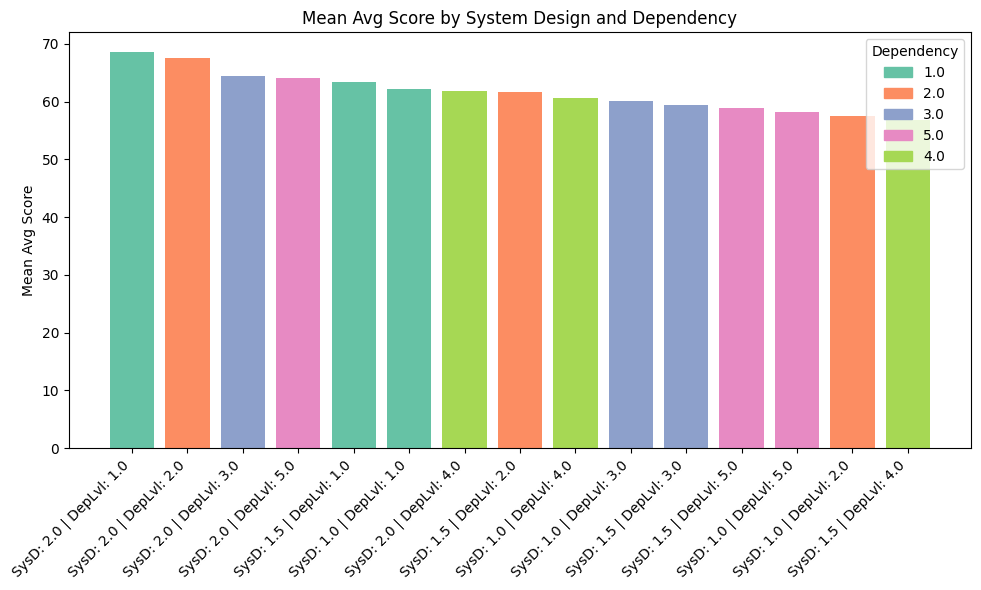

In [36]:

# Step 3: Assign a color per dependency using seaborn palette
unique_deps = pivot_both['dependency'].unique()
palette = sns.color_palette('Set2', n_colors=len(unique_deps))
color_map = dict(zip(unique_deps, palette))
bar_colors = pivot_both['dependency'].map(color_map)

# Step 4: Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(pivot_both['label'], pivot_both['mean'], color=bar_colors)

# Step 5: Customize plot
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean Avg Score')
plt.title('Mean Avg Score by System Design and Dependency')
plt.tight_layout()

# Add legend
handles = [plt.Rectangle((0,0),1,1, color=color_map[d]) for d in unique_deps]
labels = [str(d) for d in unique_deps]
ax.legend(handles, labels, title='Dependency')

plt.show()



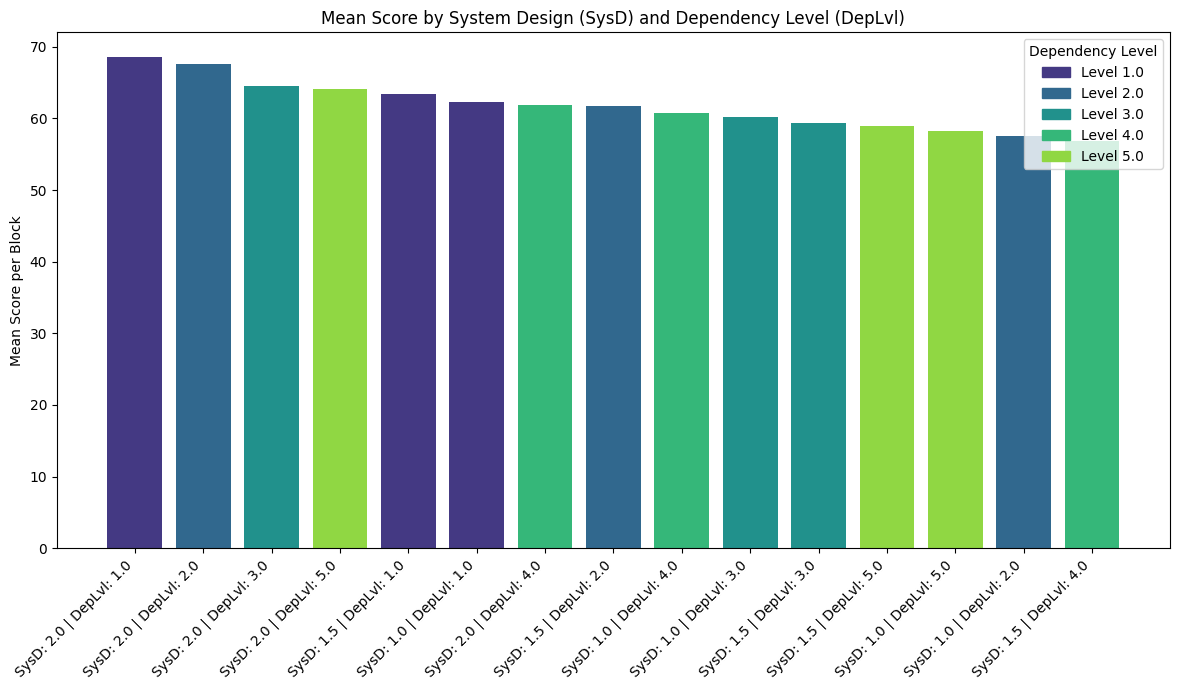

In [37]:
# --- FINAL CORRECTED CODE FOR PLOTTING ---
# Step 1: Aggregate data using the correct dataframe and column names
# Use 'ds_purchased_df', 'dependency', and 'score_mean'
pivot_both = (
    df_p
    .groupby(['system_d', 'dependency'])['score_mean']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)

# Step 2: Create the plot label, converting both numeric columns to strings
pivot_both['label'] = (
    'SysD: ' + pivot_both['system_d'].astype(str) +
    ' | DepLvl: ' + pivot_both['dependency'].astype(str)
)

# Sort the values for a cleaner plot
pivot_both = pivot_both.sort_values(by='mean', ascending=False)


# Step 3: Assign a color for each dependency level
# Use 'dependency' here as well
unique_deps = sorted(pivot_both['dependency'].unique())
palette = sns.color_palette('viridis', n_colors=len(unique_deps))
color_map = dict(zip(unique_deps, palette))
bar_colors = pivot_both['dependency'].map(color_map)


# Step 4: Plot the data
fig, ax = plt.subplots(figsize=(12, 7))
ax.bar(pivot_both['label'], pivot_both['mean'], color=bar_colors)


# Step 5: Customize the plot for readability
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean Score per Block')
plt.title('Mean Score by System Design (SysD) and Dependency Level (DepLvl)')
plt.tight_layout()


# Step 6: Add a clear legend
handles = [plt.Rectangle((0,0),1,1, color=color_map[d]) for d in unique_deps]
labels = [f"Level {d}" for d in unique_deps]
ax.legend(handles, labels, title='Dependency Level')

plt.show()

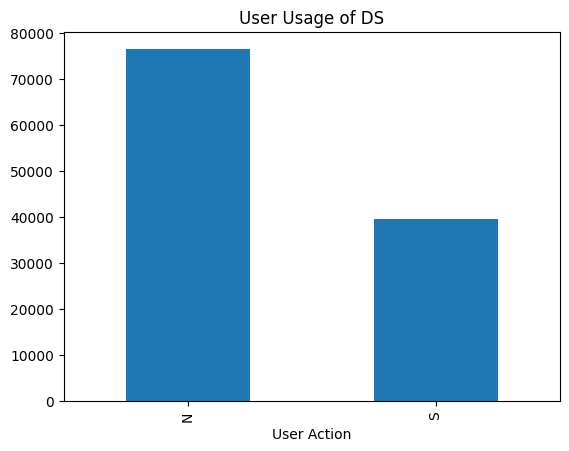

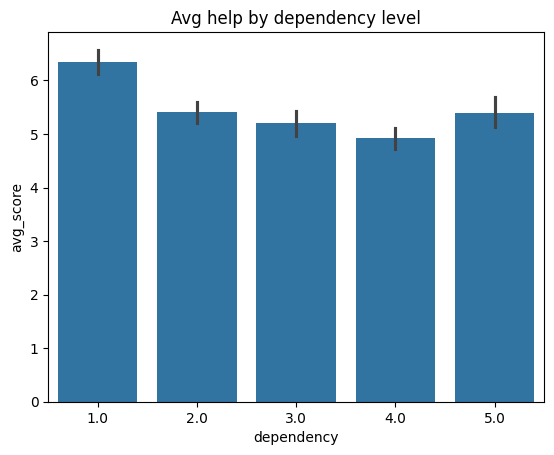

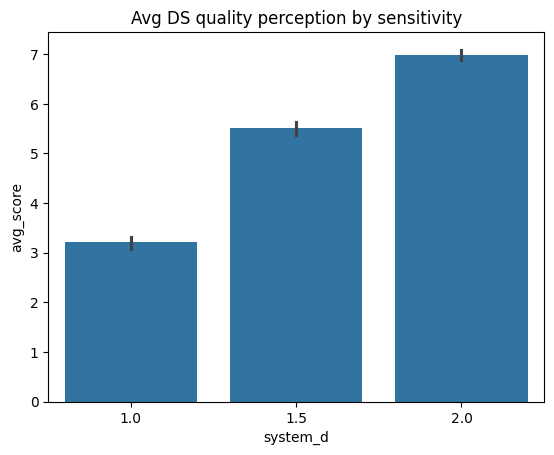

In [38]:
#######################################################
# 3. Question distributions — DS usage and satisfaction
# Suppose columns: 'User Action' and 'Alert_System' correspond to satisfaction?
# If you have explicit satisfaction questions in raw or agg, adjust accordingly.
df_raw['User Action'].value_counts().plot(kind='bar', title='User Usage of DS')
plt.show()

# 4. Average satisfaction (example columns avg_help from df_agg)
sns.barplot(x='dependency', y='avg_score', data=df_p)
plt.title('Avg help by dependency level')
plt.show()

sns.barplot(x='system_d', y='avg_score', data=df_p)
plt.title('Avg DS quality perception by sensitivity')
plt.show()

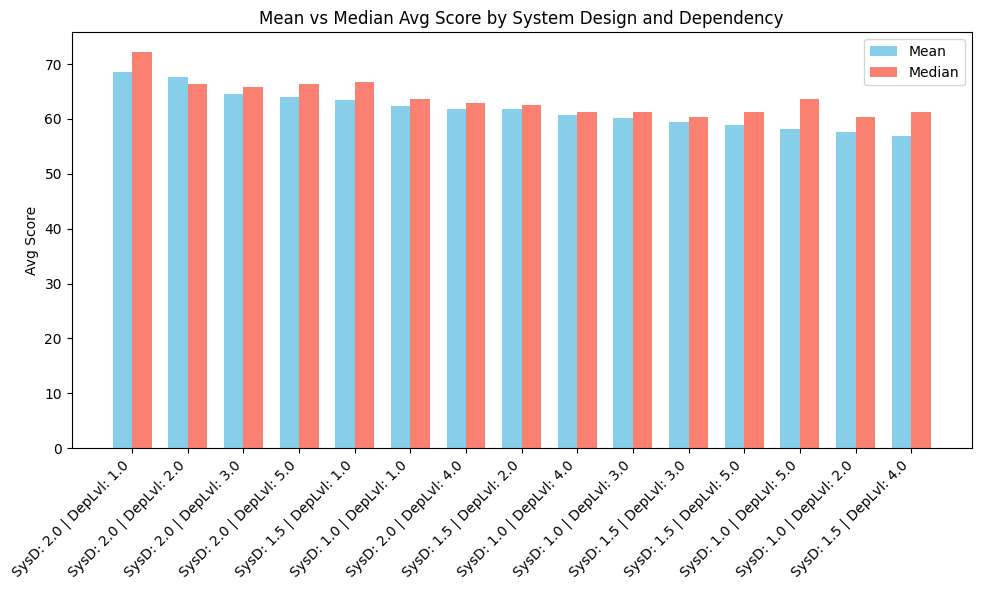

In [39]:
########################################################
import numpy as np

x = np.arange(len(pivot_both))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, pivot_both['mean'], width, label='Mean', color='skyblue')
ax.bar(x + width/2, pivot_both['median'], width, label='Median', color='salmon')

ax.set_xticks(x)
ax.set_xticklabels(pivot_both['label'], rotation=45, ha='right')
ax.set_ylabel('Avg Score')
ax.set_title('Mean vs Median Avg Score by System Design and Dependency')
ax.legend()
plt.tight_layout()
plt.show()

### Model

In [40]:
# 0.  Basic housekeeping
# -------------------------------------------------------------
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [41]:
# 1.  Target & feature matrix
# -------------------------------------------------------------
y = df_p['avg_score']              # <-- the “avg_score” per id,block
# X = df_p.drop(columns=['avg_score','distinguishing_score','help_task_score','dependency','id','dependency'])
X = df_p.drop(columns=['avg_score','distinguishing_score','help_task_score','id','dep_1','dep_2','dep_3','dep_4','dep_5'])

# quick peek
print("shape:", X.shape, "features:", X.columns.tolist()[:10], "...")

shape: (1347, 17) features: ['block', 'system_d', 'score_mean', 'score_max', 'stimulus_mean', 'stimulus_median', 'stimulus_max', 'classification_time_mean', 'classification_time_median', 'classification_time_max'] ...


In [42]:
# 2.  Column typing
# -------------------------------------------------------------
numeric_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(exclude='number').columns.tolist()

preproc = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", "passthrough", categorical_cols)  # already one-hot or ordinal
        ],
        remainder='drop'
)
print('numeric cols:', numeric_cols)
print('categorical cols:', categorical_cols)

numeric cols: ['block', 'system_d', 'score_mean', 'score_max', 'stimulus_mean', 'stimulus_median', 'stimulus_max', 'classification_time_mean', 'classification_time_median', 'classification_time_max', 'classification_time_min', 'dependency', 'correct_sum', 'tp_sum', 'fp_sum', 'tn_sum', 'fn_sum']
categorical cols: []


In [43]:
df_p[numeric_cols]

,block,system_d,score_mean,score_max,stimulus_mean,stimulus_median,stimulus_max,classification_time_mean,classification_time_median,classification_time_max,classification_time_min,dependency,correct_sum,tp_sum,fp_sum,tn_sum,fn_sum
0,2,1.0,69.925,97,5.69200,5.625,8.56,3.850683,3.473090,9.416507,2.232065,1.0,32,8,4,24,4
1,5,1.0,61.975,97,5.73850,5.690,8.60,3.758988,3.418529,9.478784,2.094734,1.0,33,10,5,23,2
2,2,1.0,67.375,88,5.69200,5.625,8.56,4.287084,3.655744,10.327827,2.286189,2.0,31,8,5,23,4
3,3,1.0,42.700,70,5.74650,5.695,8.62,4.346998,3.728286,8.883751,2.350707,2.0,30,7,5,23,5
4,2,1.5,65.800,88,5.69200,5.625,8.56,3.654145,3.229200,8.675187,1.739079,4.0,31,8,5,23,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1342,3,2.0,66.325,103,5.74650,5.695,8.62,1.891416,1.551237,6.323896,0.819349,2.0,34,10,4,24,2
1343,6,2.0,66.325,109,5.74475,5.655,8.58,2.026454,1.398556,8.586062,0.849181,2.0,35,10,3,25,2
1344,2,2.0,72.775,106,5.69200,5.625,8.56,1.979797,1.335030,8.366509,0.833603,2.0,34,10,4,24,2
1345,4,2.0,64.375,109,5.73600,5.655,8.60,2.596598,1.470511,8.367864,0.881623,2.0,35,10,3,25,2


In [44]:
# 3.  Prepare three simple models
# -------------------------------------------------------------
models = {
    'Linear'  : LinearRegression(),
    'RF'      : RandomForestRegressor(
                    n_estimators=300,
                    max_depth=None,
                    n_jobs=-1,
                    random_state=42),
    'GBR'     : GradientBoostingRegressor(
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=3,
                    random_state=42)
}

scores = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preproc), ('model', model)])
    cv_rmse = -cross_val_score(pipe, X, y,
                               scoring='neg_root_mean_squared_error',
                               cv=5, n_jobs=-1).mean()
    scores[name] = cv_rmse
    print(f"{name:8s}  CV-RMSE = {cv_rmse:0.3f}")

best_name = min(scores, key=scores.get)
print("\nBest model so far:", best_name, "  (lower RMSE is better)")

Linear    CV-RMSE = 1.189
RF        CV-RMSE = 1.316
GBR       CV-RMSE = 1.283

Best model so far: Linear   (lower RMSE is better)


In [45]:
# --- 1. Enhanced Model Evaluation ---

# Define the metrics we want to track
scoring_metrics = {
    'R-squared': 'r2',
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error'
}

print("--- Re-evaluating models with more metrics (5-fold CV) ---")

# Dataframe to store clean results
results_list = []

# Using the fixed data (X) and the existing preprocessor (preproc_fixed)
for name, model in models.items():
    pipe = Pipeline([('prep', preproc), ('model', model)])
    
    # Use cross_validate to get multiple scores
    scores = cross_validate(pipe, X, y,
                            scoring=scoring_metrics,
                            cv=5, n_jobs=-1,
                            return_train_score=False)
    
    # Store results in a dictionary
    results = {
        'Model': name,
        'R-squared': f"{scores['test_R-squared'].mean():.3f} ± {scores['test_R-squared'].std():.3f}",
        'MAE': f"{-scores['test_MAE'].mean():.3f} ± {-scores['test_MAE'].std():.3f}",
        'RMSE': f"{-scores['test_RMSE'].mean():.3f} ± {-scores['test_RMSE'].std():.3f}"
    }
    results_list.append(results)

# Display results in a clean table
results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

--- Re-evaluating models with more metrics (5-fold CV) ---
 Model     R-squared            MAE           RMSE
Linear 0.523 ± 0.187 0.948 ± -0.192 1.189 ± -0.235
    RF 0.432 ± 0.150 1.065 ± -0.181 1.316 ± -0.204
   GBR 0.454 ± 0.156 1.022 ± -0.155 1.283 ± -0.183


In [46]:
# --- 2. Hyperparameter Tuning for Tree Models ---
# from sklearn.model_selection import train_test_split, RandomizedSearchCV
# from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# from scipy.stats import randint, uniform
# import pprint
# # --- FINAL CORRECTED CODE for Test Set Evaluation ---
# import numpy as np # Make sure numpy is imported


# First, create a stable train/test split from your fixed data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Define parameter search spaces ---
# The 'model__' prefix tells the pipeline to apply the parameter to the 'model' step
rf_params = {
    'model__n_estimators': randint(100, 600),
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': randint(2, 11),
    'model__min_samples_leaf': randint(1, 11)
}

gbr_params = {
    'model__n_estimators': randint(100, 600),
    'model__learning_rate': uniform(0.01, 0.2),
    'model__max_depth': randint(2, 8),
    'model__subsample': uniform(0.7, 0.3) # (loc, scale) -> range is [0.7, 1.0]
}

# --- Set up and run RandomizedSearchCV for Random Forest ---
pipe_rf = Pipeline([('prep', preproc), ('model', RandomForestRegressor(random_state=42, n_jobs=-1))])
search_rf = RandomizedSearchCV(
    pipe_rf, param_distributions=rf_params, n_iter=50, cv=5,
    scoring='neg_root_mean_squared_error', n_jobs=-1, random_state=42, verbose=1
)
print("\n--- Tuning RandomForestRegressor ---")
search_rf.fit(X_train, y_train)


# --- Set up and run RandomizedSearchCV for Gradient Boosting ---
pipe_gbr = Pipeline([('prep', preproc), ('model', GradientBoostingRegressor(random_state=42))])
search_gbr = RandomizedSearchCV(
    pipe_gbr, param_distributions=gbr_params, n_iter=50, cv=5,
    scoring='neg_root_mean_squared_error', n_jobs=-1, random_state=42, verbose=1
)
print("\n--- Tuning GradientBoostingRegressor ---")
search_gbr.fit(X_train, y_train)

# --- Report Best Parameters ---
print("\n--- Tuning Complete ---")
print(f"Best RF CV RMSE: {-search_rf.best_score_:.3f}")
print("Best RF Parameters found:")
pprint.pprint(search_rf.best_params_)

print(f"\nBest GBR CV RMSE: {-search_gbr.best_score_:.3f}")
print("Best GBR Parameters found:")
pprint.pprint(search_gbr.best_params_)


# --- Final Evaluation on the Held-Out Test Set ---
best_rf = search_rf.best_estimator_
best_gbr = search_gbr.best_estimator_
# We also need to fit the baseline linear model to compare fairly
pipe_linear = Pipeline([('prep', preproc), ('model', models['Linear'])])
pipe_linear.fit(X_train, y_train)


# Make predictions on the unseen test data
pred_linear = pipe_linear.predict(X_test)
pred_rf = best_rf.predict(X_test)
pred_gbr = best_gbr.predict(X_test)

# Report final scores using np.sqrt() for RMSE
print("\n--- Final Test Set Performance ---")

# **FIX APPLIED HERE:** Use np.sqrt(mean_squared_error(...))
print(f"Linear:   RMSE={np.sqrt(mean_squared_error(y_test, pred_linear)):.3f}, R2={r2_score(y_test, pred_linear):.3f}")
print(f"Tuned RF: RMSE={np.sqrt(mean_squared_error(y_test, pred_rf)):.3f}, R2={r2_score(y_test, pred_rf):.3f}")
print(f"Tuned GBR: RMSE={np.sqrt(mean_squared_error(y_test, pred_gbr)):.3f}, R2={r2_score(y_test, pred_gbr):.3f}")


--- Tuning RandomForestRegressor ---
Fitting 5 folds for each of 50 candidates, totalling 250 fits

--- Tuning GradientBoostingRegressor ---
Fitting 5 folds for each of 50 candidates, totalling 250 fits

--- Tuning Complete ---
Best RF CV RMSE: 1.132
Best RF Parameters found:
{'model__max_depth': 10,
 'model__min_samples_leaf': 10,
 'model__min_samples_split': 5,
 'model__n_estimators': 409}

Best GBR CV RMSE: 1.117
Best GBR Parameters found:
{'model__learning_rate': np.float64(0.013193250444042839),
 'model__max_depth': 3,
 'model__n_estimators': 439,
 'model__subsample': np.float64(0.7723076398078035)}

--- Final Test Set Performance ---
Linear:   RMSE=1.168, R2=0.666
Tuned RF: RMSE=1.146, R2=0.678
Tuned GBR: RMSE=1.145, R2=0.679


In [47]:
df_p.columns

Index(['id', 'block', 'system_d', 'help_task_score', 'distinguishing_score',
       'avg_score', 'dep_1', 'dep_2', 'dep_3', 'dep_4', 'dep_5', 'score_mean',
       'score_max', 'stimulus_mean', 'stimulus_median', 'stimulus_max',
       'classification_time_mean', 'classification_time_median',
       'classification_time_max', 'classification_time_min', 'dependency',
       'correct_sum', 'tp_sum', 'fp_sum', 'tn_sum', 'fn_sum'],
      dtype='object')

### Feature Importance Analysis

/var/folders/19/tgcx3l5d53s090pxf4c256w80000gn/T/ipykernel_73977/1707772450.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='inferno')


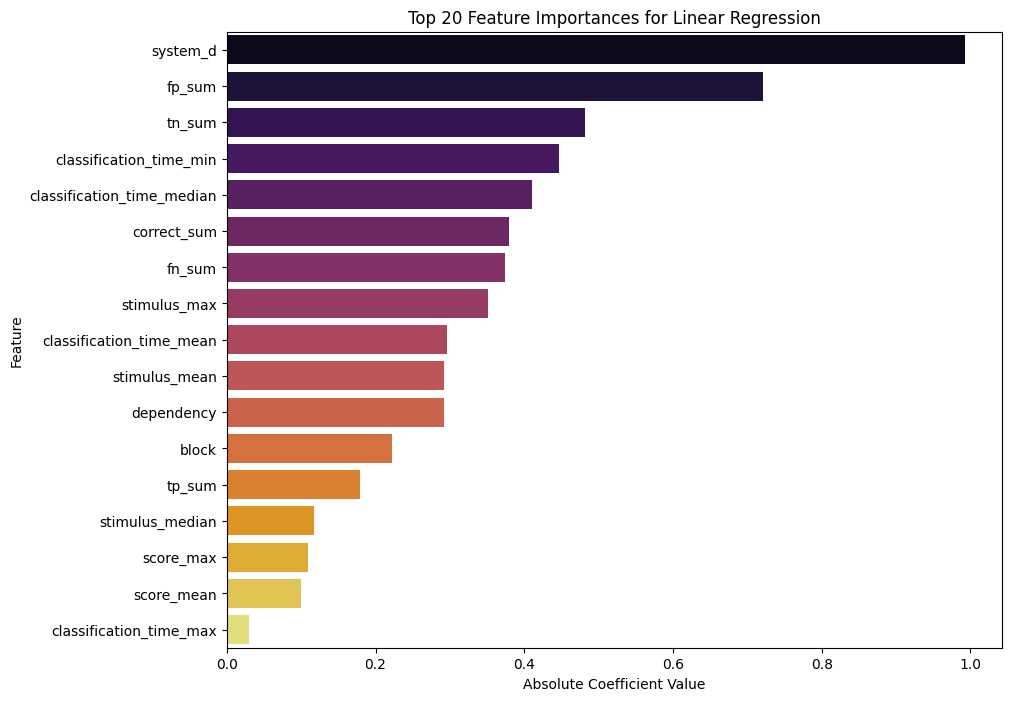

In [48]:
# --- 1. Linear Model Feature Importance ---

# Get the fitted preprocessor and model from the final linear pipeline
fitted_preprocessor = pipe_linear.named_steps['prep']
final_model = pipe_linear.named_steps['model']

# Get the final feature names after one-hot encoding
try:
    categorical_features_out = fitted_preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
    final_feature_names = numeric_cols + list(categorical_features_out)
except (AttributeError, TypeError):
    final_feature_names = numeric_cols# In case there are no categorical features

# Create a DataFrame of the coefficients
importance_df = pd.DataFrame({
    'Feature': final_feature_names,
    'Importance': np.abs(final_model.coef_)
}).sort_values(by='Importance', ascending=False)

# Plot the results
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='inferno')
plt.title('Top 20 Feature Importances for Linear Regression')
plt.xlabel('Absolute Coefficient Value')
plt.show()

/var/folders/19/tgcx3l5d53s090pxf4c256w80000gn/T/ipykernel_73977/328105923.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_importance_df.head(20), palette='viridis')


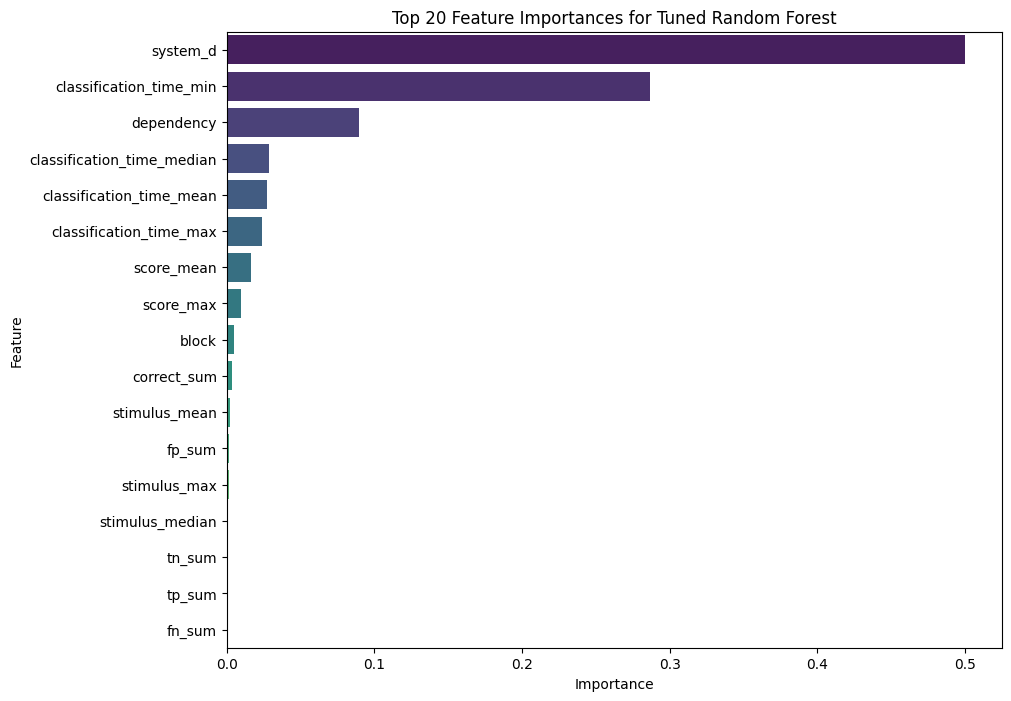

In [49]:
# --- 2. Random Forest Feature Importance ---

# Get the fitted model and preprocessor from the tuned RF pipeline
final_rf_model = best_rf.named_steps['model']
rf_preprocessor = best_rf.named_steps['prep']

# Get the final feature names (same logic as before)
try:
    rf_cat_features = rf_preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
    rf_final_features = numeric_cols + list(rf_cat_features)
except (AttributeError, TypeError):
    rf_final_features = numeric_cols

# Create the importance DataFrame
rf_importance_df = pd.DataFrame({
    'Feature': rf_final_features,
    'Importance': final_rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot the results
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=rf_importance_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importances for Tuned Random Forest')
plt.show()

SHAP Summary Plot for Tuned Gradient Boosting Model:


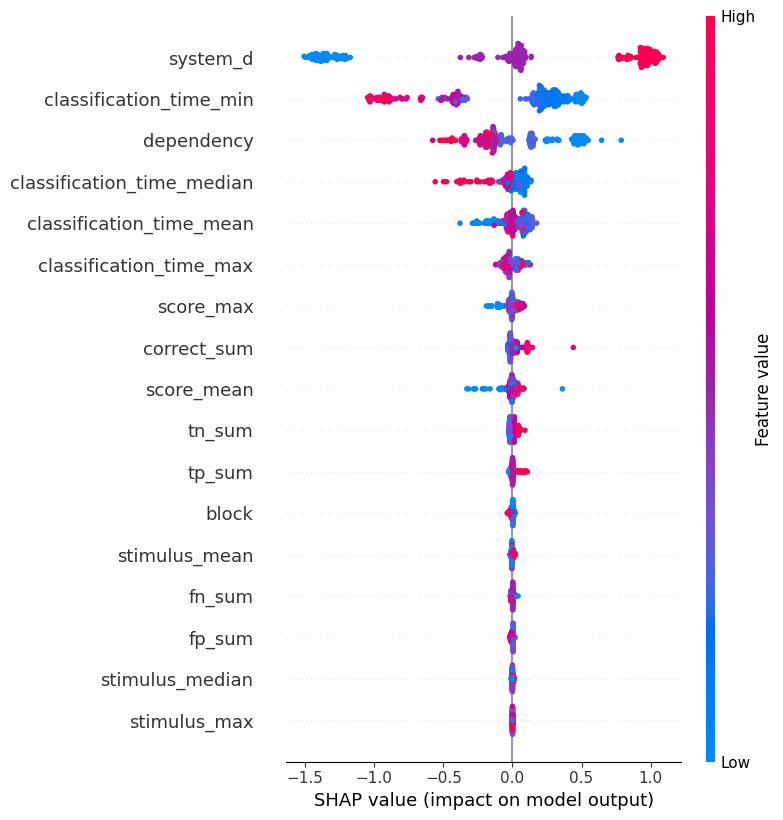

In [50]:
# --- 3. SHAP Summary for Gradient Boosting Regressor ---
import shap

# Get the fitted GBR model and preprocessor
final_gbr_model = best_gbr.named_steps['model']
gbr_preprocessor = best_gbr.named_steps['prep']

# We need to transform the test data using the fitted preprocessor
X_test_transformed = gbr_preprocessor.transform(X_test)

# Get the final feature names after transformation
try:
    gbr_cat_features = gbr_preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
    gbr_final_features = numeric_cols + list(gbr_cat_features)
except (AttributeError, TypeError):
    gbr_final_features = numeric_cols

# Create the SHAP explainer and calculate SHAP values
explainer = shap.TreeExplainer(final_gbr_model)
shap_values = explainer.shap_values(X_test_transformed)

# Create the SHAP summary plot
print("SHAP Summary Plot for Tuned Gradient Boosting Model:")
shap.summary_plot(
    shap_values,
    pd.DataFrame(X_test_transformed, columns=gbr_final_features),
    max_display=20
)

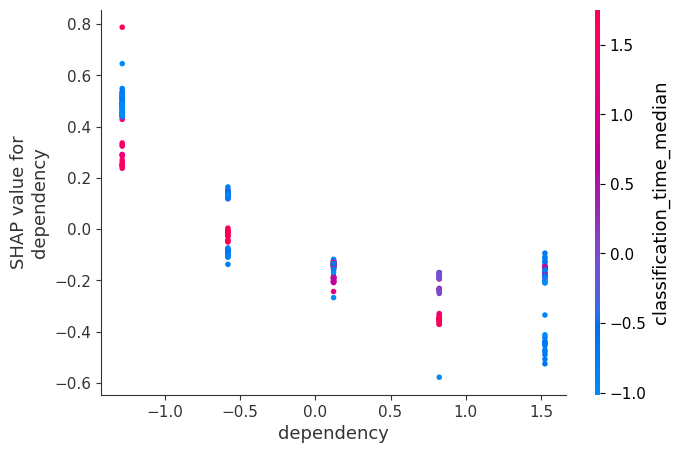

In [51]:
shap.dependence_plot('dependency', shap_values,
                        pd.DataFrame(X_test_transformed, columns=gbr_final_features))

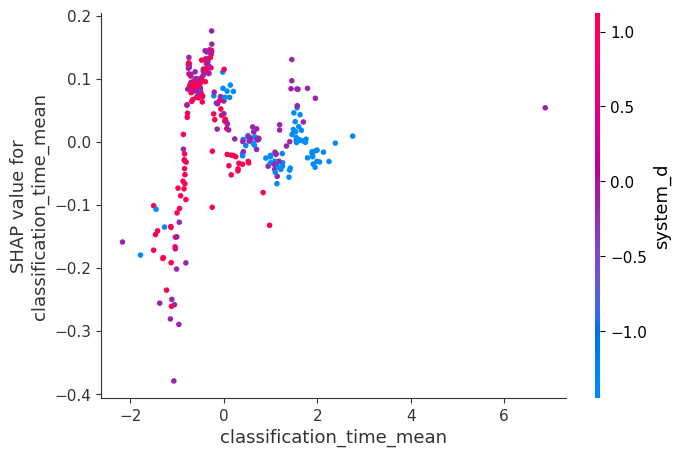

In [52]:
shap.dependence_plot('classification_time_mean', shap_values,
                    pd.DataFrame(X_test_transformed, columns=gbr_final_features))
 # add here if there was first try or not in the analysis.. also check system_d is only for purchase // 

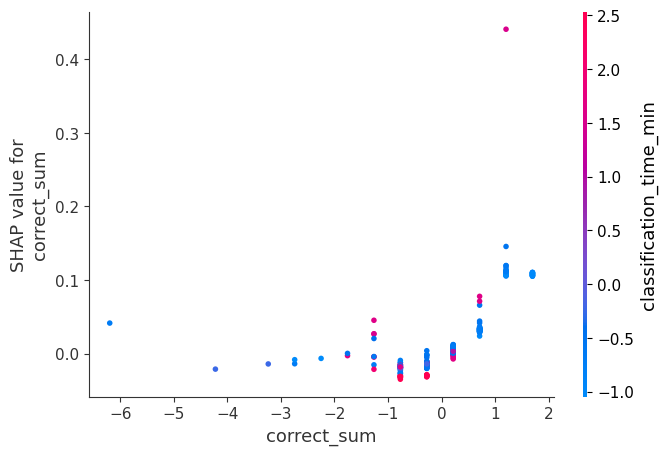

In [53]:
shap.dependence_plot('correct_sum', shap_values,
                        pd.DataFrame(X_test_transformed, columns=gbr_final_features))

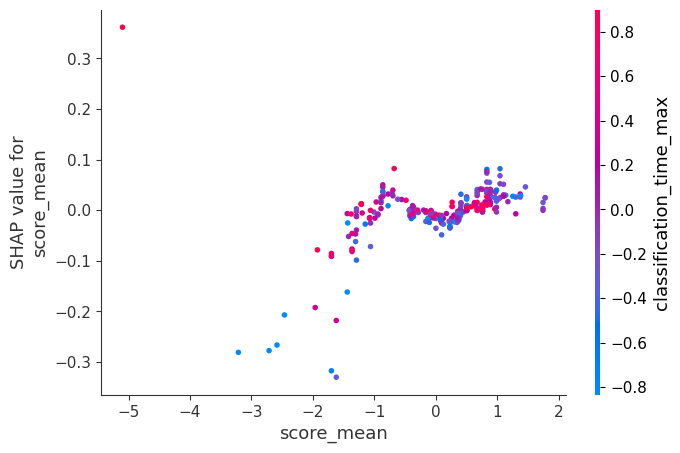

In [54]:
shap.dependence_plot('score_mean', shap_values,
                    pd.DataFrame(X_test_transformed, columns=gbr_final_features))

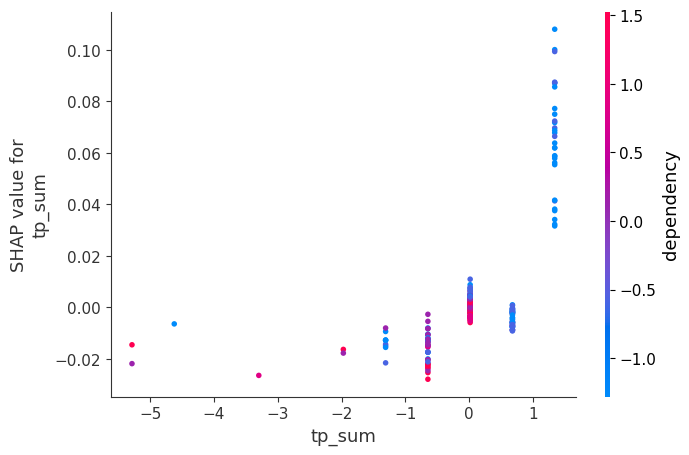

In [55]:
shap.dependence_plot('tp_sum', shap_values,
                    pd.DataFrame(X_test_transformed, columns=gbr_final_features))

### Recom

In [56]:
from sklearn.isotonic import IsotonicRegression
from sklearn.inspection import PartialDependenceDisplay       # scikit-learn ≥1.0

In [57]:
# from sklearn.inspection import plot_partial_dependence as PartialDependenceDisplay

/opt/anaconda3/envs/thesis/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 13 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


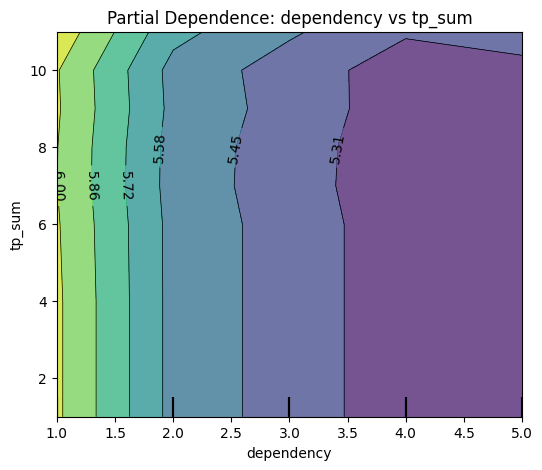

In [58]:
# -------- Calibration ------------
y_pred_val = best_gbr.predict(X_test)
iso = IsotonicRegression(out_of_bounds='clip').fit(y_pred_val, y_test)

# -------- 2-way PDP --------------
fig, ax = plt.subplots(figsize=(6,5))
PartialDependenceDisplay.from_estimator(
    best_gbr,                       # pipeline (prep → model)
    X_test,
    features=[('dependency', 'tp_sum')],
    grid_resolution=25,
    kind='average',
    ax=ax
)
plt.title('Partial Dependence: dependency vs tp_sum')
plt.show()

## Exp 2

### Raw - Analysis and EDA

In [59]:
import numpy as np
import pandas as pd

In [60]:
df_raw2 = pd.read_csv('exp2_raw.csv')
df_agg2 = pd.read_csv('exp2_agg.csv')

# 2. Quick overview
print('raw 2 info: ',df_raw2.info())
print('agg 2 info: ',df_agg2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8550 entries, 0 to 8549
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   aid                 8550 non-null   object 
 1   id                  8550 non-null   int64  
 2   condition           8550 non-null   object 
 3   system_type         8550 non-null   object 
 4   system_sensitivity  8550 non-null   object 
 5   binary              8550 non-null   int64  
 6   integrated          8550 non-null   int64  
 7   trial               8550 non-null   int64  
 8   event               8550 non-null   object 
 9   stimulus_h          8550 non-null   float64
 10  stimulus_s          8550 non-null   float64
 11  human_p             8550 non-null   float64
 12  system_p            8550 non-null   float64
 13  system_output       8550 non-null   object 
 14  strength_human      8550 non-null   float64
 15  direction_human     8550 non-null   object 
 16  pd    

In [61]:
print('agg 2 head: ') 
df_agg2.head()

agg 2 head: 


,aid,id,condition,system_type,system_sensitivity,binary,integrated,How much did the automation help you in the task?,How good was the automation in distinguishing between blue and orange Vibranium strains?
0,63f1fc10-ad7f-391a-01a9-b753784ee62d,4,binary_high,binary,high,1,0,5,4
1,63f1fdd6-633a-61f0-6122-219db0c9e175,5,binary_low,binary,low,1,0,6,6
2,63f1fe87-4d59-7fd2-b43a-88b6ceab16a3,6,likelihood_integrated_high,likelihood_integrated,high,0,1,8,8
3,63f1ffc7-1fed-874e-fe1c-62d5e1ec8081,7,likelihood_high,likelihood,high,0,0,6,6
4,63f20142-7d55-261f-7255-d0dfa40444dc,9,likelihood_high,likelihood,high,0,0,6,6


In [62]:
# Removing some features from agg: such as aid which is the same as id,
# condition is the same as system type + sensetivity so i'd keep both cause of interaction. maybe later remove. 
# system type can be removed and keep only binary/intergrated
df_agg2['high_sensitivity'] = df_agg2['system_sensitivity'] == 'high'
agg_df2 = df_agg2.drop(columns=['aid', 'condition', 'system_type','system_sensitivity'])
agg2 = agg_df2.rename(columns={
    'How much did the automation help you in the task?': 'help_task_score',
    'How good was the automation in distinguishing between blue and orange Vibranium strains?': 'distinguishing_score'
})
# Create a new column for average score
agg2['avg_score'] = agg2[['help_task_score', 'distinguishing_score']].mean(axis=1)

agg2.head()

,id,binary,integrated,help_task_score,distinguishing_score,high_sensitivity,avg_score
0,4,1,0,5,4,True,4.5
1,5,1,0,6,6,False,6.0
2,6,0,1,8,8,True,8.0
3,7,0,0,6,6,True,6.0
4,9,0,0,6,6,True,6.0


In [63]:
print('raw :')
df_raw2.head(5)

raw :


,aid,id,condition,system_type,system_sensitivity,binary,integrated,trial,event,stimulus_h,stimulus_s,human_p,system_p,system_output,strength_human,direction_human,pd,classification,score,time
0,63f1fc10-ad7f-391a-01a9-b753784ee62d,4,binary_high,binary,high,1,0,1,Blue,0.179703,2.020537,0.57,0.99,Blue,0.07,+,True,Blue,31.9,3.040691
1,63f1fc10-ad7f-391a-01a9-b753784ee62d,4,binary_high,binary,high,1,0,2,Orange,-1.465812,-3.653065,0.10,0.00,Orange,0.40,-,False,Orange,33.9,2.546419
2,63f1fc10-ad7f-391a-01a9-b753784ee62d,4,binary_high,binary,high,1,0,3,Orange,-2.495117,-1.495501,0.02,0.00,Orange,0.48,-,False,Orange,35.9,4.751094
3,63f1fc10-ad7f-391a-01a9-b753784ee62d,4,binary_high,binary,high,1,0,4,Blue,-0.171103,-0.254062,0.44,0.30,Orange,0.06,-,True,Orange,33.8,3.588098
4,63f1fc10-ad7f-391a-01a9-b753784ee62d,4,binary_high,binary,high,1,0,5,Orange,-2.038375,-1.318309,0.04,0.00,Orange,0.46,-,False,Orange,35.8,5.924426


In [64]:
df_raw2[df_raw2['id'] == 4].head()

,aid,id,condition,system_type,system_sensitivity,binary,integrated,trial,event,stimulus_h,stimulus_s,human_p,system_p,system_output,strength_human,direction_human,pd,classification,score,time
0,63f1fc10-ad7f-391a-01a9-b753784ee62d,4,binary_high,binary,high,1,0,1,Blue,0.179703,2.020537,0.57,0.99,Blue,0.07,+,True,Blue,31.9,3.040691
1,63f1fc10-ad7f-391a-01a9-b753784ee62d,4,binary_high,binary,high,1,0,2,Orange,-1.465812,-3.653065,0.10,0.00,Orange,0.40,-,False,Orange,33.9,2.546419
2,63f1fc10-ad7f-391a-01a9-b753784ee62d,4,binary_high,binary,high,1,0,3,Orange,-2.495117,-1.495501,0.02,0.00,Orange,0.48,-,False,Orange,35.9,4.751094
3,63f1fc10-ad7f-391a-01a9-b753784ee62d,4,binary_high,binary,high,1,0,4,Blue,-0.171103,-0.254062,0.44,0.30,Orange,0.06,-,True,Orange,33.8,3.588098
4,63f1fc10-ad7f-391a-01a9-b753784ee62d,4,binary_high,binary,high,1,0,5,Orange,-2.038375,-1.318309,0.04,0.00,Orange,0.46,-,False,Orange,35.8,5.924426


In [65]:
# Removing some features from raw
raw2 = df_raw2.drop(columns=['aid', 'condition','system_sensitivity','binary','integrated','strength_human'])
raw2.loc[ raw2['direction_human'] == '+', 'direction_human' ] = 'Plus'
raw2.loc[ raw2['direction_human'] == '-', 'direction_human' ] = 'Minus'
raw2.head()

,id,system_type,trial,event,stimulus_h,stimulus_s,human_p,system_p,system_output,direction_human,pd,classification,score,time
0,4,binary,1,Blue,0.179703,2.020537,0.57,0.99,Blue,Plus,True,Blue,31.9,3.040691
1,4,binary,2,Orange,-1.465812,-3.653065,0.10,0.00,Orange,Minus,False,Orange,33.9,2.546419
2,4,binary,3,Orange,-2.495117,-1.495501,0.02,0.00,Orange,Minus,False,Orange,35.9,4.751094
3,4,binary,4,Blue,-0.171103,-0.254062,0.44,0.30,Orange,Minus,True,Orange,33.8,3.588098
4,4,binary,5,Orange,-2.038375,-1.318309,0.04,0.00,Orange,Minus,False,Orange,35.8,5.924426


In [66]:
raw2.dtypes

id                   int64
system_type         object
trial                int64
event               object
stimulus_h         float64
stimulus_s         float64
human_p            float64
system_p           float64
system_output       object
direction_human     object
pd                    bool
classification      object
score              float64
time               float64
dtype: object

In [67]:
# --- Step 1: Rename and sort ---
# Rename agg columns to match raw

# Sort both dataframes by ID and Block
df_raw_sorted2 = raw2.sort_values(['id', 'trial'])
df_agg_sorted2 = agg2.sort_values(['id','help_task_score','distinguishing_score','avg_score'])

# Display the first few rows to confirm
print("Raw (sorted)", df_raw_sorted2.head())
print("Agg (renamed & sorted)", df_agg_sorted2.head())


Raw (sorted)    id system_type  trial   event  stimulus_h  stimulus_s  human_p  system_p  \
0   4      binary      1    Blue    0.179703    2.020537     0.57      0.99   
1   4      binary      2  Orange   -1.465812   -3.653065     0.10      0.00   
2   4      binary      3  Orange   -2.495117   -1.495501     0.02      0.00   
3   4      binary      4    Blue   -0.171103   -0.254062     0.44      0.30   
4   4      binary      5  Orange   -2.038375   -1.318309     0.04      0.00   

  system_output direction_human     pd classification  score      time  
0          Blue            Plus   True           Blue   31.9  3.040691  
1        Orange           Minus  False         Orange   33.9  2.546419  
2        Orange           Minus  False         Orange   35.9  4.751094  
3        Orange           Minus   True         Orange   33.8  3.588098  
4        Orange           Minus  False         Orange   35.8  5.924426  
Agg (renamed & sorted)    id  binary  integrated  help_task_score  disting

In [68]:
# 1‑A  convert Block to numeric and drop NaNs
df_raw_sorted2['trial'] = pd.to_numeric(df_raw_sorted2['trial'], errors='coerce')
df_raw_sorted2  = df_raw_sorted2.dropna(subset=['trial'])
# })

assert df_raw_sorted2.groupby('id')['trial'].apply(lambda s: s.is_monotonic_increasing).all()
print("② OK")


② OK


In [69]:
raw2.columns

Index(['id', 'system_type', 'trial', 'event', 'stimulus_h', 'stimulus_s',
       'human_p', 'system_p', 'system_output', 'direction_human', 'pd',
       'classification', 'score', 'time'],
      dtype='object')

#### Aggregating and merging:

In [70]:

def _safe_eq(a, b):
    """Vectorised equality that tolerates nan / None."""
    return (a == b) & ~(pd.isna(a) | pd.isna(b))

def engineer_row_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add trial-level features for confusion, confidence, agreement & difficulty."""
    # ----- 1A.  Ground-truth confusion wrt *human* decisions -----
    df = df.assign(
        tp=_safe_eq(df.classification, 'Blue')   & _safe_eq(df.event, 'Blue'),
        fp=_safe_eq(df.classification, 'Blue')   & _safe_eq(df.event, 'Orange'),
        tn=_safe_eq(df.classification, 'Orange') & _safe_eq(df.event, 'Orange'),
        fn=_safe_eq(df.classification, 'Orange') & _safe_eq(df.event, 'Blue'),
    )

    # ----- 1B.  What did the DS show? -----
    # • binary-only:           `system_output` is shown, `system_p` is NaN  
    # • likelihood_*:          both  shown; classification is threshold(p>0.5)
    # • likelihood_integrated: *same* as above but human sees p too
    df = df.assign(
        auto_label     = np.where(pd.notna(df.system_p),          # if a prob exists use it
                                  np.where(df.system_p > .5, 'Blue', 'Orange'),
                                  df.system_output),
        ds_conf        = np.where(pd.notna(df.system_p), (df.system_p - 0.5).abs(),
                                  np.nan)                         # confidence only when p given
    )

    # ----- 1C.  Agreements (vectorised, honouring NaNs) -----
    df = df.assign(
        agree_all   = _safe_eq(df.classification, df.auto_label).astype('float'),
        agree_prob  = np.where(pd.notna(df.system_p),
                               ((_safe_eq(df.classification, 'Blue') & (df.system_p > .5)) |
                                (_safe_eq(df.classification, 'Orange') & (df.system_p <= .5)))
                               .astype('float'),
                               np.nan),
        agree_when_pd = np.where(df.pd,
                                 _safe_eq(df.classification, df.auto_label).astype('float'),
                                 np.nan),
    )

    # ----- 1D.  Extra difficulty signal from stimulus_s (signed distance) -----
    df = df.assign(
        difficulty = df.stimulus_s.abs()               # larger mag → clearer evidence
    )

    return df


In [71]:
agg_funcs = {
    # confusion counts
    'tp':   'sum', 'fp':'sum', 'tn':'sum', 'fn':'sum',

    # agreements
    'agree_all':     'mean',
    'agree_prob':    'mean',
    'agree_when_pd': 'mean',

    # DS usage & confidence
    'pd':        'mean',                     # purchase rate
    'ds_conf':  ['mean', 'median', 'max'],

    # evidence difficulty
    'difficulty': ['mean', 'median'],

    # human bias
    'direction_human': lambda s: (s == 'Plus').mean(),

    # base-rate of Blue events
    'event': lambda s: (s == 'Blue').mean(),

    # performance & timing
    'score': ['mean','median','max','min'],
    'time':  ['mean','median','max','min'],
}

user_agg2 = (engineer_row_features(raw2)
             .groupby('id')
             .agg(agg_funcs)
             .rename(columns={'pd':'ds_purchase_rate'}))

# flatten MultiIndex columns
user_agg2.columns = ['_'.join(c).strip('_') if isinstance(c, tuple) else c
                     for c in user_agg2.columns.to_flat_index()]
user_agg2

,tp_sum,fp_sum,tn_sum,fn_sum,agree_all_mean,agree_prob_mean,agree_when_pd_mean,ds_purchase_rate_mean,ds_conf_mean,ds_conf_median,...,direction_human_<lambda>,event_<lambda>,score_mean,score_median,score_max,score_min,time_mean,time_median,time_max,time_min
id,,,,,,,,,,,,,,,,,,,,,
4,21,5,20,4,0.86,0.86,0.913043,0.46,0.4116,0.475,...,0.46,0.5,64.278,64.80,93.8,31.9,4.775221,4.790148,9.804271,1.257381
5,19,5,20,6,0.92,0.92,1.000000,0.06,0.3098,0.320,...,0.46,0.5,56.550,55.90,85.7,26.0,3.887308,3.413990,7.932933,1.082329
6,20,3,22,5,0.96,0.96,1.000000,0.44,0.4116,0.475,...,0.46,0.5,57.930,56.70,95.8,25.9,4.838082,4.141531,10.919378,1.233818
7,21,2,23,4,0.82,0.82,0.944444,0.36,0.3716,0.430,...,0.46,0.5,68.830,70.85,104.2,31.9,4.719580,4.523588,10.814245,1.189046
9,22,3,22,3,0.78,0.78,0.882353,0.34,0.3716,0.430,...,0.46,0.5,71.844,72.60,104.3,32.0,5.336394,4.502240,13.285067,1.713122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,20,4,21,5,0.72,0.72,0.818182,0.22,0.3716,0.430,...,0.46,0.5,62.266,60.50,94.9,32.0,4.563733,4.216345,14.716608,1.061804
596,21,3,22,4,0.86,0.86,0.904762,0.42,0.4116,0.475,...,0.46,0.5,67.668,63.85,99.9,31.9,4.642841,4.322733,10.132926,1.199710
597,17,4,21,8,0.66,0.66,1.000000,0.04,0.1430,0.115,...,0.46,0.5,57.328,58.00,81.8,28.0,4.316224,3.952222,11.164154,1.457045


so i can see that every participant  got 23 plus and 27 minus trials and that tthe experiment was balandced like in the article. so 25 for each

In [72]:
user_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                481 non-null    int64  
 1   dep_1             481 non-null    bool   
 2   dep_2             481 non-null    bool   
 3   dep_3             481 non-null    bool   
 4   dep_4             481 non-null    bool   
 5   dep_5             481 non-null    bool   
 6   blocks_purchased  481 non-null    int64  
 7   user_score_avg    481 non-null    float64
 8   user_score_max    481 non-null    int64  
 9   stim_avg          481 non-null    float64
 10  stim_med          481 non-null    float64
 11  stim_max          481 non-null    float64
 12  total_correct     481 non-null    int64  
 13  total_tp          481 non-null    int64  
 14  total_fp          481 non-null    int64  
 15  total_tn          481 non-null    int64  
 16  total_fn          481 non-null    int64  
 1

In [73]:
agg2.head()

,id,binary,integrated,help_task_score,distinguishing_score,high_sensitivity,avg_score
0,4,1,0,5,4,True,4.5
1,5,1,0,6,6,False,6.0
2,6,0,1,8,8,True,8.0
3,7,0,0,6,6,True,6.0
4,9,0,0,6,6,True,6.0


In [74]:
user_raw_agg   = user_agg2.copy()  
df_exp2    = agg2.copy() 

# ------------------------------------------------------------------
# 1.  Remove columns that would leak the target
# ------------------------------------------------------------------
cols_to_drop = ['help_task_score', 'distinguishing_score']   # avg-score proxies
df_exp2 = df_exp2.drop(columns=cols_to_drop, errors='ignore')

# ------------------------------------------------------------------
# 2.  Merge on user id  (left join keeps all behaviour rows)
# ------------------------------------------------------------------
merged2 = (
    user_raw_agg
    .merge(df_exp2, on='id', how='left',
           validate='1:1',       # sanity-check: each id appears once in exp-2
           suffixes=('', '_exp2'))
)
merged2

,id,tp_sum,fp_sum,tn_sum,fn_sum,agree_all_mean,agree_prob_mean,agree_when_pd_mean,ds_purchase_rate_mean,ds_conf_mean,...,score_max,score_min,time_mean,time_median,time_max,time_min,binary,integrated,high_sensitivity,avg_score
0,4,21,5,20,4,0.86,0.86,0.913043,0.46,0.4116,...,93.8,31.9,4.775221,4.790148,9.804271,1.257381,1,0,True,4.5
1,5,19,5,20,6,0.92,0.92,1.000000,0.06,0.3098,...,85.7,26.0,3.887308,3.413990,7.932933,1.082329,1,0,False,6.0
2,6,20,3,22,5,0.96,0.96,1.000000,0.44,0.4116,...,95.8,25.9,4.838082,4.141531,10.919378,1.233818,0,1,True,8.0
3,7,21,2,23,4,0.82,0.82,0.944444,0.36,0.3716,...,104.2,31.9,4.719580,4.523588,10.814245,1.189046,0,0,True,6.0
4,9,22,3,22,3,0.78,0.78,0.882353,0.34,0.3716,...,104.3,32.0,5.336394,4.502240,13.285067,1.713122,0,0,True,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,595,20,4,21,5,0.72,0.72,0.818182,0.22,0.3716,...,94.9,32.0,4.563733,4.216345,14.716608,1.061804,0,0,True,5.5
167,596,21,3,22,4,0.86,0.86,0.904762,0.42,0.4116,...,99.9,31.9,4.642841,4.322733,10.132926,1.199710,1,0,True,4.5
168,597,17,4,21,8,0.66,0.66,1.000000,0.04,0.1430,...,81.8,28.0,4.316224,3.952222,11.164154,1.457045,0,0,False,2.0
169,598,17,7,18,8,0.88,0.88,1.000000,0.04,0.3098,...,71.9,32.0,4.518640,4.510408,10.612409,1.196307,1,0,False,3.0


#### Viz

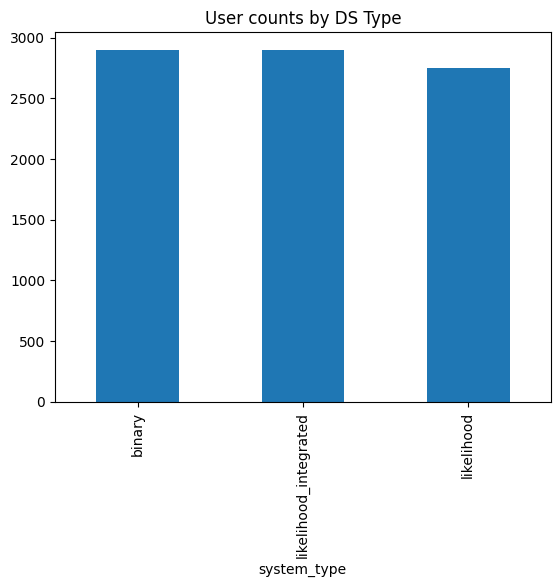

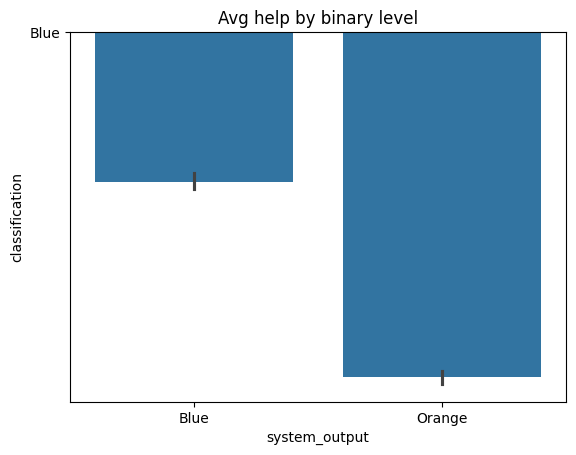

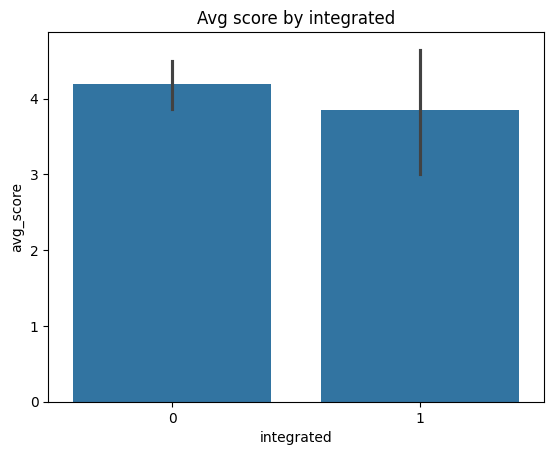

In [75]:
#######################################################
# 3. Question distributions — DS usage
# Suppose columns: 'User Action' and 'Alert_System' correspond to satisfaction?
# If you have explicit satisfaction questions in raw or agg, adjust accordingly.
raw2['system_type'].value_counts().plot(kind='bar', title='User counts by DS Type')
plt.show()

# 4. Average satisfaction (example columns avg_help from df_agg)
sns.barplot(x='system_output', y='classification', data=raw2)
plt.title('Avg help by binary level')
plt.show()

# 5. Average satisfaction (example columns avg_help from df_agg)
sns.barplot(x='integrated', y='avg_score', data=merged2)
plt.title('Avg score by integrated')
plt.show()


### Improving models features according to the output

In [76]:
df = merged2.copy()  # your per-id table

# precision / recall / F1 from counts
tp = df.get('tp_sum', 0)
fp = df.get('fp_sum', 0)
fn = df.get('fn_sum', 0)

precision = (tp / (tp + fp).replace(0, np.nan)).fillna(0.0)
recall    = (tp / (tp + fn).replace(0, np.nan)).fillna(0.0)
f1        = (2 * precision * recall / (precision + recall).replace(0, np.nan)).fillna(0.0)

df['precision'] = precision
df['f1'] = f1

# drop confusion-matrix counts (keep only precision & f1)
df = df.drop(columns=['tp_sum','fp_sum','tn_sum','fn_sum'], errors='ignore')

# drop score_mean/score_median but keep score_max
df = df.drop(columns=['score_mean','score_median'], errors='ignore')

# keep only time_mean (drop the rest)
time_cols_to_drop = [c for c in df.columns if c.startswith('time_') and c != 'time_mean']
df = df.drop(columns=time_cols_to_drop, errors='ignore')

# Booleans → ints (SimpleImputer dislikes bool)
bool_cols = df.select_dtypes('bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# Choose target and features


In [77]:
# --------------------------------------------------
# 1.  Pick target & feature columns
# --------------------------------------------------
target   = 'avg_score'
# drop any old “exp2” version of the target
merged2 = merged2.drop(columns=['avg_score_exp2'], errors='ignore')

y = merged2[target]
X = df.drop(columns=['avg_score'], errors='ignore')  # keep score_max AS FEATURE if desired
X = X.drop(columns=['direction_human_<lambda>','event_<lambda>','id'])
# X = merged2.drop(columns=[target, 'id'])

In [78]:
# log for skewed time
if 'time_mean' in X.columns:
    X['time_mean_log'] = np.log1p(X['time_mean'])

# a couple of linear interactions often useful
for a, b, name in [
    ('difficulty_mean','time_mean','diff_x_time'),
    ('ds_conf_mean','ds_purchase_rate_mean','conf_x_purchase'),
]:
    if a in X.columns and b in X.columns:
        X[name] = X[a] * X[b]

In [79]:
X.isnull().sum()

agree_all_mean           0
agree_prob_mean          0
agree_when_pd_mean       1
ds_purchase_rate_mean    0
ds_conf_mean             0
ds_conf_median           0
ds_conf_max              0
difficulty_mean          0
difficulty_median        0
score_max                0
score_min                0
time_mean                0
binary                   0
integrated               0
high_sensitivity         0
precision                0
f1                       0
time_mean_log            0
diff_x_time              0
conf_x_purchase          0
dtype: int64

In [80]:
# Remove rows in X where the 'agree_when_pd_mean' column is missing (NaN)
mask = ~X['agree_when_pd_mean'].isna()
X = X[mask]
y = y[mask]

#### new updated spine linear models + tuned RF

In [81]:
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler, SplineTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split, cross_validate
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

# assumes X, y already defined (pruned)
numeric_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(exclude='number').columns.tolist()

spline_features = [c for c in ['difficulty_mean','ds_conf_mean','time_mean'] if c in numeric_cols]
plain_numeric   = [c for c in numeric_cols if c not in spline_features]

preproc_linear = ColumnTransformer(
    transformers=[
        ('num_spline', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('spline', SplineTransformer(n_knots=5, degree=3, include_bias=False)),
            ('scale', StandardScaler())
        ]), spline_features),
        ('num_plain', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('scale', StandardScaler())
        ]), plain_numeric),
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols),
    ],
    remainder='drop'
)

preproc_rf = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), selector(dtype_include=np.number)),
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), selector(dtype_exclude=np.number)),
    ],
    remainder='drop'
)

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [83]:
enet = Pipeline([('prep', preproc_linear), ('model', ElasticNet(max_iter=50000))])
enet_grid = {'model__alpha': np.logspace(-3, 2, 30), 'model__l1_ratio': [0.2,0.4,0.6,0.8]}
enet_cv = GridSearchCV(enet, enet_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=0)
enet_cv.fit(X_train, y_train)
best_enet = enet_cv.best_estimator_

scores = cross_validate(best_enet, X, y, cv=5,
                        scoring={'rmse':'neg_root_mean_squared_error','r2':'r2'},
                        n_jobs=-1, return_train_score=False)
print(f"ENet(splines)   CV   RMSE={-scores['test_rmse'].mean():.3f} ± {scores['test_rmse'].std():.3f}  "
      f"R2={scores['test_r2'].mean():.3f} ± {scores['test_r2'].std():.3f}")

pred = best_enet.predict(X_test)
print(f"ENet(splines)   Test RMSE={np.sqrt(mean_squared_error(y_test,pred)):.3f}  R2={r2_score(y_test,pred):.3f}  "
      f"MAE={mean_absolute_error(y_test,pred):.3f}  params={enet_cv.best_params_}")

ENet(splines)   CV   RMSE=1.492 ± 0.334  R2=0.553 ± 0.208
ENet(splines)   Test RMSE=1.501  R2=0.568  MAE=1.162  params={'model__alpha': np.float64(0.1743328822199989), 'model__l1_ratio': 0.2}


In [84]:
rf = Pipeline([('prep', preproc_rf),
               ('model', RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1))])

scores_rf = cross_validate(rf, X, y, cv=5,
                           scoring={'rmse':'neg_root_mean_squared_error','r2':'r2'},
                           n_jobs=-1, return_train_score=False)
print(f"RandomForest     CV   RMSE={-scores_rf['test_rmse'].mean():.3f} ± {scores_rf['test_rmse'].std():.3f}  "
      f"R2={scores_rf['test_r2'].mean():.3f} ± {scores_rf['test_r2'].std():.3f}")

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print(f"RandomForest     Test RMSE={np.sqrt(mean_squared_error(y_test,pred_rf)):.3f}  R2={r2_score(y_test,pred_rf):.3f}")

RandomForest     CV   RMSE=1.421 ± 0.243  R2=0.595 ± 0.150
RandomForest     Test RMSE=1.386  R2=0.632


/var/folders/19/tgcx3l5d53s090pxf4c256w80000gn/T/ipykernel_73977/2378483827.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lin_imp, x='importance', y='feature', palette='magma', hue=None, legend=False)


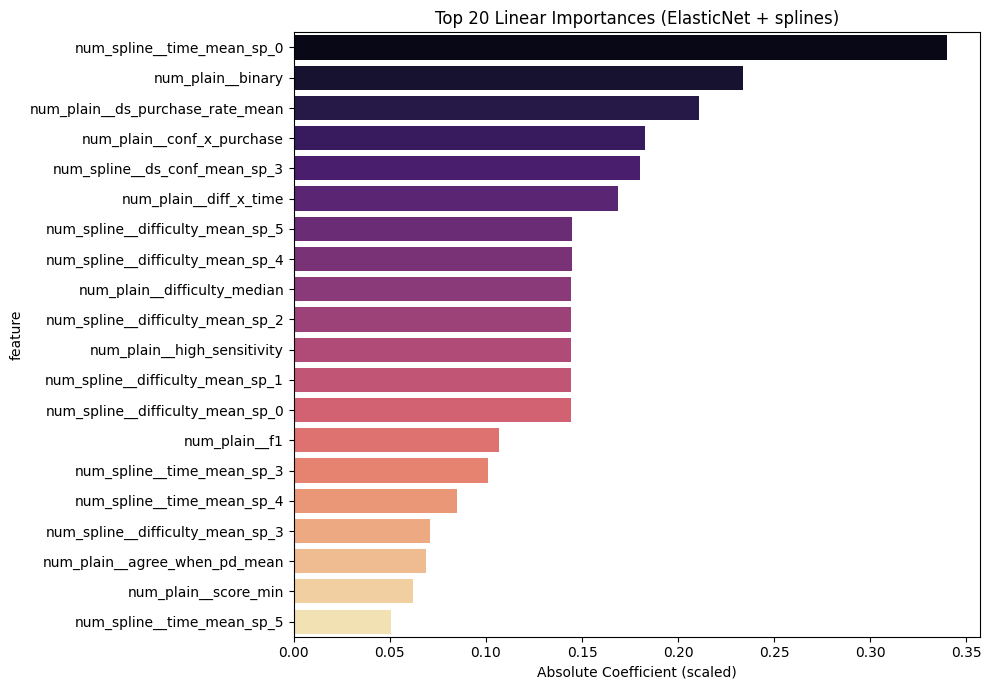

In [85]:
fprep = best_enet.named_steps['prep']
try:
    # sklearn >=1.2
    lin_feature_names = fprep.get_feature_names_out()
except Exception:
    # fallback (basic)
    lin_feature_names = list(numeric_cols) + (fprep.named_transformers_['cat'].named_steps['ohe']
                                              .get_feature_names_out(categorical_cols).tolist()
                                              if categorical_cols else [])

coefs = best_enet.named_steps['model'].coef_
lin_imp = (pd.DataFrame({'feature': lin_feature_names, 'importance': np.abs(coefs)})
           .sort_values('importance', ascending=False).head(20))

plt.figure(figsize=(10,7))
sns.barplot(data=lin_imp, x='importance', y='feature', palette='magma', hue=None, legend=False)
plt.title("Top 20 Linear Importances (ElasticNet + splines)")
plt.xlabel("Absolute Coefficient (scaled)")
plt.tight_layout(); plt.show()

/var/folders/19/tgcx3l5d53s090pxf4c256w80000gn/T/ipykernel_73977/3510587698.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis', hue=None, legend=False)


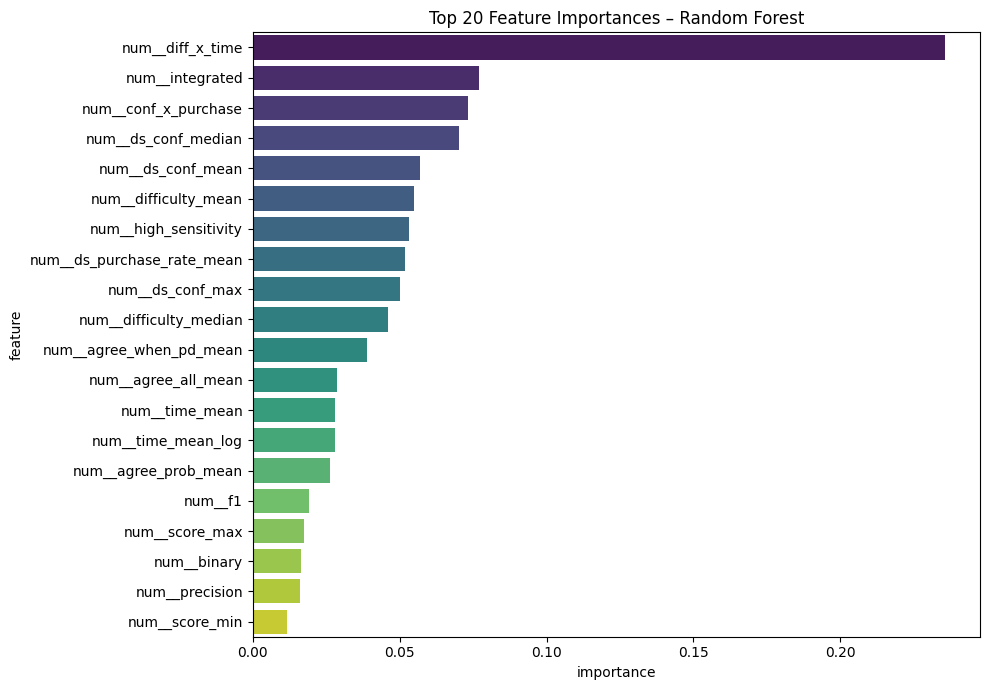

In [86]:
# after rf.fit(...) and after you computed X_test
rf_prep = rf.named_steps['prep']
Xt_rf = rf_prep.transform(X_test)  # this is exactly what the model sees
rf_model = rf.named_steps['model']

# Try to get proper feature names; fall back to generic if unavailable
try:
    rf_feature_names = rf_prep.get_feature_names_out().tolist()
except Exception:
    rf_feature_names = [f'feat_{i}' for i in range(Xt_rf.shape[1])]

imp_df = (pd.DataFrame({'feature': rf_feature_names,
                        'importance': rf_model.feature_importances_})
          .sort_values('importance', ascending=False).head(20))

plt.figure(figsize=(10,7))
sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis', hue=None, legend=False)
plt.title("Top 20 Feature Importances – Random Forest")
plt.tight_layout(); plt.show()

/opt/anaconda3/envs/thesis/lib/python3.12/site-packages/shap/explainers/_tree.py:253: FutureWarning: In the future, passing feature_perturbation='interventional' without providing a background dataset will raise an error. Please provide a background dataset to continue using the interventional approach or set feature_perturbation='auto' to automatically switch approaches.
  warnings.warn(


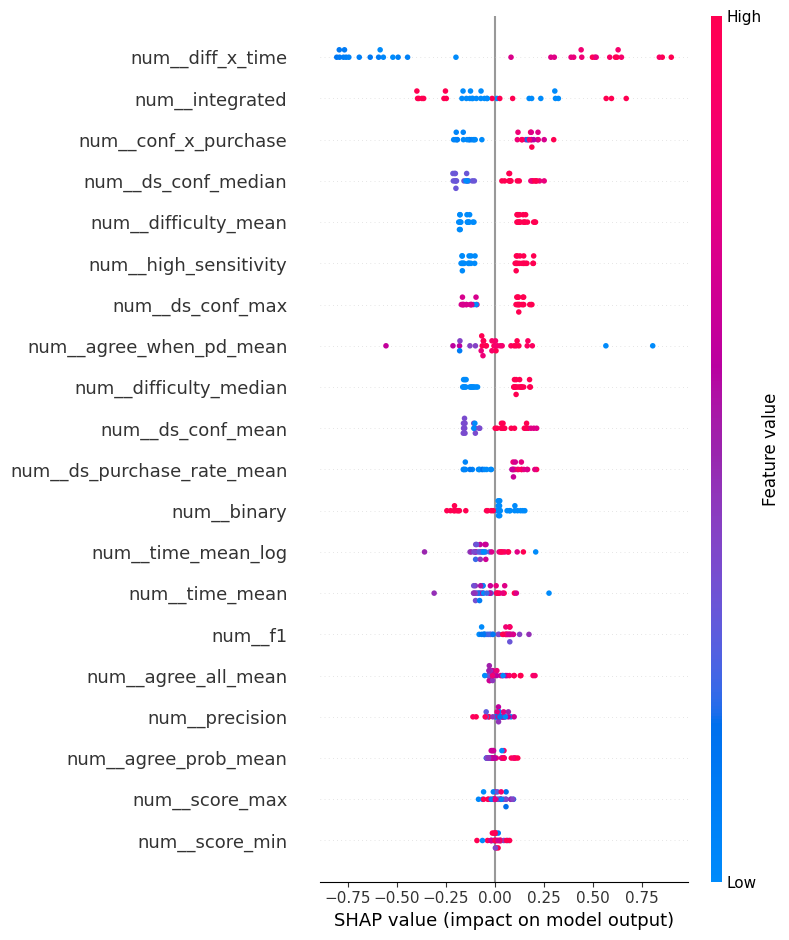

In [87]:
import shap

# Use the same transformed matrix, and relax additivity check
explainer = shap.TreeExplainer(
    rf_model,
    feature_perturbation='interventional',   # more robust with preprocessed features
    model_output='raw'
)
shap_values = explainer.shap_values(Xt_rf, check_additivity=False)

shap.summary_plot(
    shap_values,
    pd.DataFrame(Xt_rf, columns=rf_feature_names),
    max_display=20
)

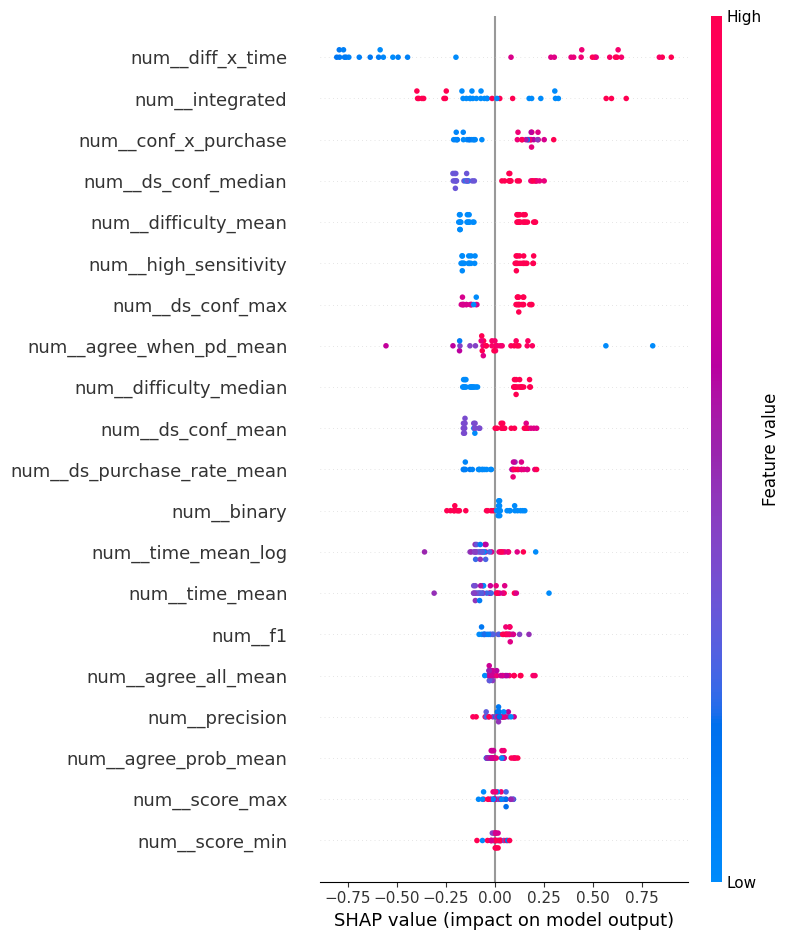

In [88]:
# === 3) SHAP for RF (on transformed test matrix) ===
import shap
X_test_rf = rf.named_steps['prep'].transform(X_test)
explainer = shap.TreeExplainer(rf.named_steps['model'])
shap_values = explainer.shap_values(X_test_rf)

shap.summary_plot(shap_values,
                  pd.DataFrame(X_test_rf, columns=rf_feature_names),
                  max_display=20)

### Models (wihtout interaction and spine - basic)

In [89]:
merged2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        171 non-null    int64  
 1   tp_sum                    171 non-null    int64  
 2   fp_sum                    171 non-null    int64  
 3   tn_sum                    171 non-null    int64  
 4   fn_sum                    171 non-null    int64  
 5   agree_all_mean            171 non-null    float64
 6   agree_prob_mean           171 non-null    float64
 7   agree_when_pd_mean        170 non-null    float64
 8   ds_purchase_rate_mean     171 non-null    float64
 9   ds_conf_mean              171 non-null    float64
 10  ds_conf_median            171 non-null    float64
 11  ds_conf_max               171 non-null    float64
 12  difficulty_mean           171 non-null    float64
 13  difficulty_median         171 non-null    float64
 14  direction_

In [90]:
from sklearn.compose    import ColumnTransformer
from sklearn.pipeline   import Pipeline
from sklearn.impute     import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.linear_model      import LinearRegression
from sklearn.ensemble          import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score, log_loss
import numpy as np
import pandas as pd

# 1. define X and Y (already done before)
# --------------------------------------------------
# 2.  Build  preprocessor
# --------------------------------------------------
# before building numeric_cols / categorical_cols
bool_cols = X.select_dtypes('bool').columns
X[bool_cols] = X[bool_cols].astype(int)        #  True→1, False→0

bool_cols = X.select_dtypes('bool').columns.tolist()

numeric_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = (
        X.select_dtypes(exclude=['int64','float64']).columns
        .difference(bool_cols)            # everything except numeric and bool
        .tolist() + bool_cols             # add bools to the cat list
)

preproc = ColumnTransformer(
    [('num', StandardScaler(), numeric_cols),
     ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)]
)

numeric_cols = X.select_dtypes(include='number').columns.tolist()
categorical_cols = X.select_dtypes(exclude='number').columns.tolist()

preproc = ColumnTransformer(
    [('num', StandardScaler(), numeric_cols),
     ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)]
)

# ... cross_val_score loop ...

preproc = ColumnTransformer(
    transformers=[
      ('num', Pipeline([
           ('impute', SimpleImputer(strategy='median')),
           ('scale',  StandardScaler())
       ]), numeric_cols),
      ('cat', Pipeline([
           ('impute', SimpleImputer(strategy='most_frequent')),
           ('ohe',    OneHotEncoder(handle_unknown='ignore'))
       ]), categorical_cols),
    ]
)
print("✓ preproc will be applied to:\n  • num:", numeric_cols,"\n  • cat:", categorical_cols)

# --------------------------------------------------
# 3.  Prepare three simple models
# --------------------------------------------------
models = {
  'Linear': LinearRegression(),
  'RF':     RandomForestRegressor(
               n_estimators=300,
               max_depth=None,
               n_jobs=-1,
               random_state=42),
  'GBR':    GradientBoostingRegressor(
               n_estimators=300,
               learning_rate=0.05,
               max_depth=3,
               random_state=42)
}

# --------------------------------------------------
# 4.  Cross-validate each with extra metrics
# --------------------------------------------------
# Define scoring metrics
scoring = {
    'r2': 'r2',
    'neg_root_mean_squared_error': 'neg_root_mean_squared_error',
    'neg_mean_absolute_error': 'neg_mean_absolute_error'
}

# For logloss: only meaningful if y is discrete (classification), but here it's regression.
# We'll try to compute logloss if y is integer and has a small number of unique values.
# Otherwise, skip logloss for regression.

can_logloss = False
if pd.api.types.is_integer_dtype(y) and y.nunique() < 20:
    can_logloss = True
    def logloss_scorer(y_true, y_pred):
        # y_pred is continuous, so we need to convert to probabilities for log_loss
        # We'll round predictions to nearest integer and one-hot encode
        y_pred_rounded = np.clip(np.round(y_pred), y_true.min(), y_true.max()).astype(int)
        classes = np.arange(y_true.min(), y_true.max()+1)
        y_true_oh = np.eye(len(classes))[y_true - y_true.min()]
        y_pred_oh = np.eye(len(classes))[y_pred_rounded - y_true.min()]
        # Add small epsilon to avoid log(0)
        eps = 1e-15
        y_pred_oh = np.clip(y_pred_oh, eps, 1 - eps)
        return log_loss(y_true_oh, y_pred_oh)
    scoring['log_loss'] = make_scorer(logloss_scorer, greater_is_better=False)

scores = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preproc), ('model', model)])
    cv_results = cross_validate(
        pipe, X, y,
        scoring=scoring,
        cv=5,
        n_jobs=-1,
        return_train_score=False
    )
    rmse = -cv_results['test_neg_root_mean_squared_error'].mean()
    r2 = cv_results['test_r2'].mean()
    mae = -cv_results['test_neg_mean_absolute_error'].mean()
    msg = f"{name:8s}  CV-RMSE = {rmse:.3f} | R2 = {r2:.3f} | MAE = {mae:.3f}"
    if can_logloss and 'test_log_loss' in cv_results:
        logloss = -cv_results['test_log_loss'].mean()
        msg += f" | LogLoss = {logloss:.3f}"
    print(msg)
    scores[name] = rmse

best_name = min(scores, key=scores.get)
print("\nBest model so far:", best_name, "(lower RMSE is better)")


✓ preproc will be applied to:
  • num: ['agree_all_mean', 'agree_prob_mean', 'agree_when_pd_mean', 'ds_purchase_rate_mean', 'ds_conf_mean', 'ds_conf_median', 'ds_conf_max', 'difficulty_mean', 'difficulty_median', 'score_max', 'score_min', 'time_mean', 'binary', 'integrated', 'high_sensitivity', 'precision', 'f1', 'time_mean_log', 'diff_x_time', 'conf_x_purchase'] 
  • cat: []
Linear    CV-RMSE = 1.500 | R2 = 0.546 | MAE = 1.134
RF        CV-RMSE = 1.417 | R2 = 0.597 | MAE = 0.937
GBR       CV-RMSE = 1.526 | R2 = 0.540 | MAE = 1.009

Best model so far: RF (lower RMSE is better)


In [91]:
# quick peek
print("shape:", X.shape, "features:", X.columns.tolist()[:10], "...")

shape: (170, 20) features: ['agree_all_mean', 'agree_prob_mean', 'agree_when_pd_mean', 'ds_purchase_rate_mean', 'ds_conf_mean', 'ds_conf_median', 'ds_conf_max', 'difficulty_mean', 'difficulty_median', 'score_max'] ...


In [92]:
# --- 1. Enhanced Model Evaluation ---

# Define the metrics we want to track
scoring_metrics = {
    'R-squared': 'r2',
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error'
}

print("--- Re-evaluating models with more metrics (5-fold CV) ---")

# Dataframe to store clean results
results_list = []

# Using the fixed data (X) and the existing preprocessor (preproc_fixed)
for name, model in models.items():
    pipe = Pipeline([('prep', preproc), ('model', model)])
    
    # Use cross_validate to get multiple scores
    scores = cross_validate(pipe, X, y,
                            scoring=scoring_metrics,
                            cv=5, n_jobs=-1,
                            return_train_score=False)
    
    # Store results in a dictionary
    results = {
        'Model': name,
        'R-squared': f"{scores['test_R-squared'].mean():.3f} ± {scores['test_R-squared'].std():.3f}",
        'MAE': f"{-scores['test_MAE'].mean():.3f} ± {-scores['test_MAE'].std():.3f}",
        'RMSE': f"{-scores['test_RMSE'].mean():.3f} ± {-scores['test_RMSE'].std():.3f}"
    }
    results_list.append(results)

# Display results in a clean table
results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

--- Re-evaluating models with more metrics (5-fold CV) ---
 Model     R-squared            MAE           RMSE
Linear 0.546 ± 0.206 1.134 ± -0.143 1.500 ± -0.311
    RF 0.597 ± 0.153 0.937 ± -0.134 1.417 ± -0.250
   GBR 0.540 ± 0.152 1.009 ± -0.099 1.526 ± -0.243


In [93]:
# --- 2. Hyperparameter Tuning for Tree Models ---
# from sklearn.model_selection import train_test_split, RandomizedSearchCV
# from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# from scipy.stats import randint, uniform
# import pprint
# # --- FINAL CORRECTED CODE for Test Set Evaluation ---
# import numpy as np # Make sure numpy is imported


# First, create a stable train/test split from your fixed data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Define parameter search spaces ---
# The 'model__' prefix tells the pipeline to apply the parameter to the 'model' step
rf_params = {
    'model__n_estimators': randint(100, 600),
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': randint(2, 11),
    'model__min_samples_leaf': randint(1, 11)
}

gbr_params = {
    'model__n_estimators': randint(100, 600),
    'model__learning_rate': uniform(0.01, 0.2),
    'model__max_depth': randint(2, 8),
    'model__subsample': uniform(0.7, 0.3) # (loc, scale) -> range is [0.7, 1.0]
}

# --- Set up and run RandomizedSearchCV for Random Forest ---
pipe_rf = Pipeline([('prep', preproc), ('model', RandomForestRegressor(random_state=42, n_jobs=-1))])
search_rf = RandomizedSearchCV(
    pipe_rf, param_distributions=rf_params, n_iter=50, cv=5,
    scoring='neg_root_mean_squared_error', n_jobs=-1, random_state=42, verbose=1
)
print("\n--- Tuning RandomForestRegressor ---")
search_rf.fit(X_train, y_train)


# --- Set up and run RandomizedSearchCV for Gradient Boosting ---
pipe_gbr = Pipeline([('prep', preproc), ('model', GradientBoostingRegressor(random_state=42))])
search_gbr = RandomizedSearchCV(
    pipe_gbr, param_distributions=gbr_params, n_iter=50, cv=5,
    scoring='neg_root_mean_squared_error', n_jobs=-1, random_state=42, verbose=1
)
print("\n--- Tuning GradientBoostingRegressor ---")
search_gbr.fit(X_train, y_train)

# --- Report Best Parameters ---
print("\n--- Tuning Complete ---")
print(f"Best RF CV RMSE: {-search_rf.best_score_:.3f}")
print("Best RF Parameters found:")
pprint.pprint(search_rf.best_params_)

print(f"\nBest GBR CV RMSE: {-search_gbr.best_score_:.3f}")
print("Best GBR Parameters found:")
pprint.pprint(search_gbr.best_params_)


# --- Final Evaluation on the Held-Out Test Set ---
best_rf = search_rf.best_estimator_
best_gbr = search_gbr.best_estimator_
# We also need to fit the baseline linear model to compare fairly
pipe_linear = Pipeline([('prep', preproc), ('model', models['Linear'])])
pipe_linear.fit(X_train, y_train)


# Make predictions on the unseen test data
pred_linear = pipe_linear.predict(X_test)
pred_rf = best_rf.predict(X_test)
pred_gbr = best_gbr.predict(X_test)

# Report final scores using np.sqrt() for RMSE
print("\n--- Final Test Set Performance ---")

# **FIX APPLIED HERE:** Use np.sqrt(mean_squared_error(...))
print(f"Linear:   RMSE={np.sqrt(mean_squared_error(y_test, pred_linear)):.3f}, R2={r2_score(y_test, pred_linear):.3f}")
print(f"Tuned RF: RMSE={np.sqrt(mean_squared_error(y_test, pred_rf)):.3f}, R2={r2_score(y_test, pred_rf):.3f}")
print(f"Tuned GBR: RMSE={np.sqrt(mean_squared_error(y_test, pred_gbr)):.3f}, R2={r2_score(y_test, pred_gbr):.3f}")


--- Tuning RandomForestRegressor ---
Fitting 5 folds for each of 50 candidates, totalling 250 fits

--- Tuning GradientBoostingRegressor ---
Fitting 5 folds for each of 50 candidates, totalling 250 fits

--- Tuning Complete ---
Best RF CV RMSE: 1.212
Best RF Parameters found:
{'model__max_depth': None,
 'model__min_samples_leaf': 9,
 'model__min_samples_split': 6,
 'model__n_estimators': 233}

Best GBR CV RMSE: 1.254
Best GBR Parameters found:
{'model__learning_rate': np.float64(0.050343840467079244),
 'model__max_depth': 2,
 'model__n_estimators': 151,
 'model__subsample': np.float64(0.8689826715929151)}

--- Final Test Set Performance ---
Linear:   RMSE=1.663, R2=0.470
Tuned RF: RMSE=1.658, R2=0.473
Tuned GBR: RMSE=1.408, R2=0.620


#### Old Feature Importance Analysis

/var/folders/19/tgcx3l5d53s090pxf4c256w80000gn/T/ipykernel_73977/1707772450.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='inferno')


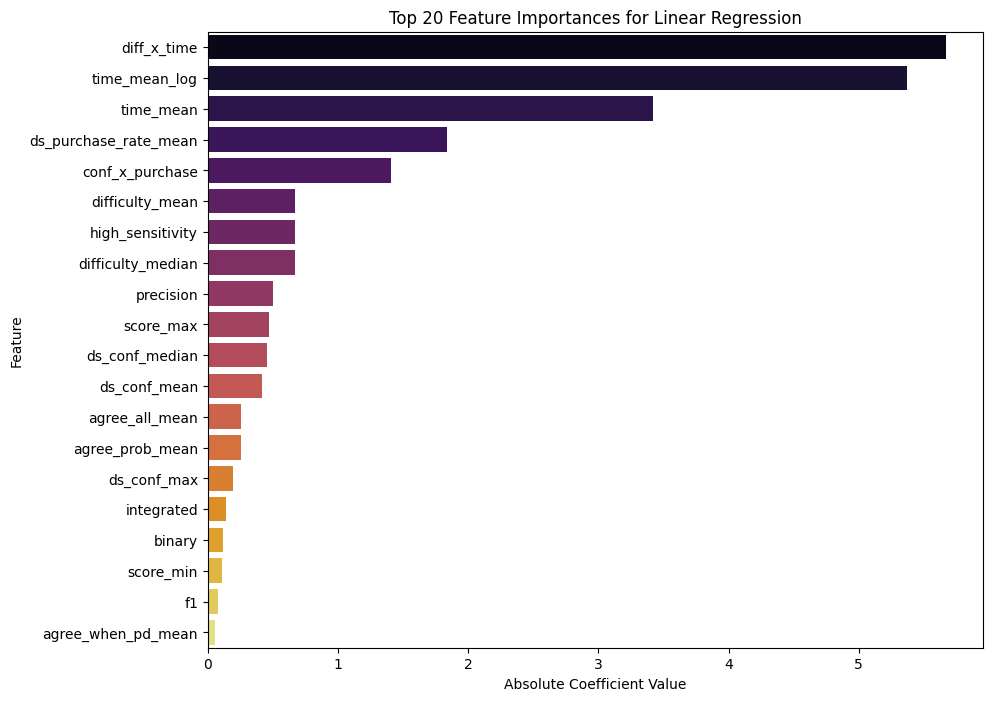

In [94]:
# --- 1. Linear Model Feature Importance ---

# Get the fitted preprocessor and model from the final linear pipeline
fitted_preprocessor = pipe_linear.named_steps['prep']
final_model = pipe_linear.named_steps['model']

# Get the final feature names after one-hot encoding
try:
    categorical_features_out = fitted_preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
    final_feature_names = numeric_cols + list(categorical_features_out)
except (AttributeError, TypeError):
    final_feature_names = numeric_cols# In case there are no categorical features

# Create a DataFrame of the coefficients
importance_df = pd.DataFrame({
    'Feature': final_feature_names,
    'Importance': np.abs(final_model.coef_)
}).sort_values(by='Importance', ascending=False)

# Plot the results
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='inferno')
plt.title('Top 20 Feature Importances for Linear Regression')
plt.xlabel('Absolute Coefficient Value')
plt.show()

/var/folders/19/tgcx3l5d53s090pxf4c256w80000gn/T/ipykernel_73977/328105923.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_importance_df.head(20), palette='viridis')


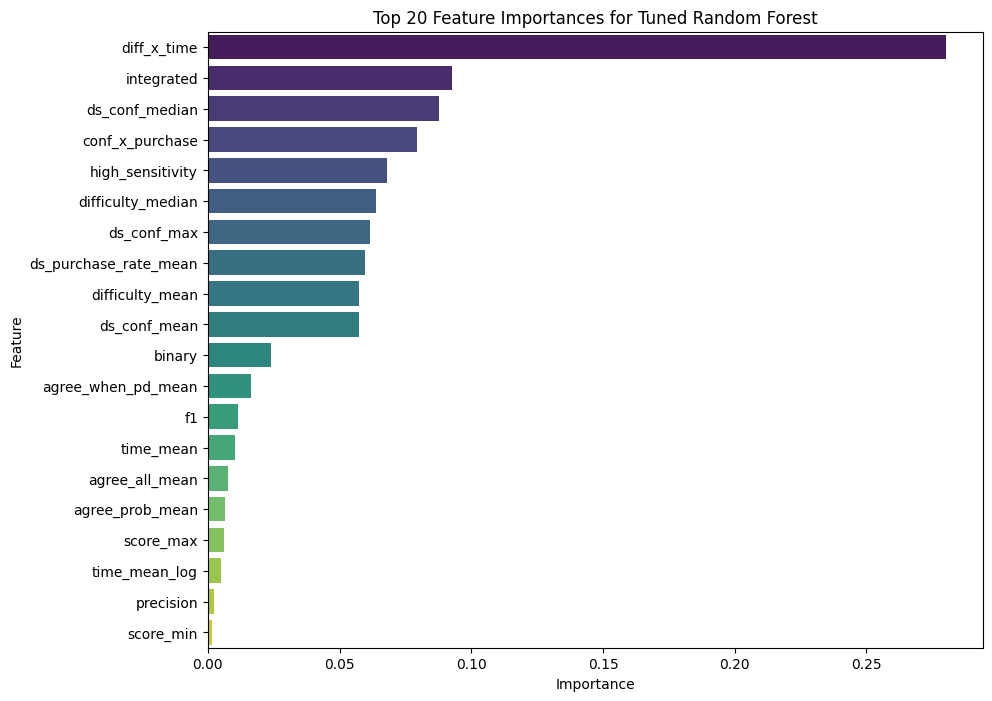

In [95]:
# --- 2. Random Forest Feature Importance ---

# Get the fitted model and preprocessor from the tuned RF pipeline
final_rf_model = best_rf.named_steps['model']
rf_preprocessor = best_rf.named_steps['prep']

# Get the final feature names (same logic as before)
try:
    rf_cat_features = rf_preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
    rf_final_features = numeric_cols + list(rf_cat_features)
except (AttributeError, TypeError):
    rf_final_features = numeric_cols

# Create the importance DataFrame
rf_importance_df = pd.DataFrame({
    'Feature': rf_final_features,
    'Importance': final_rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot the results
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=rf_importance_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importances for Tuned Random Forest')
plt.show()

SHAP Summary Plot for Tuned Gradient Boosting Model:


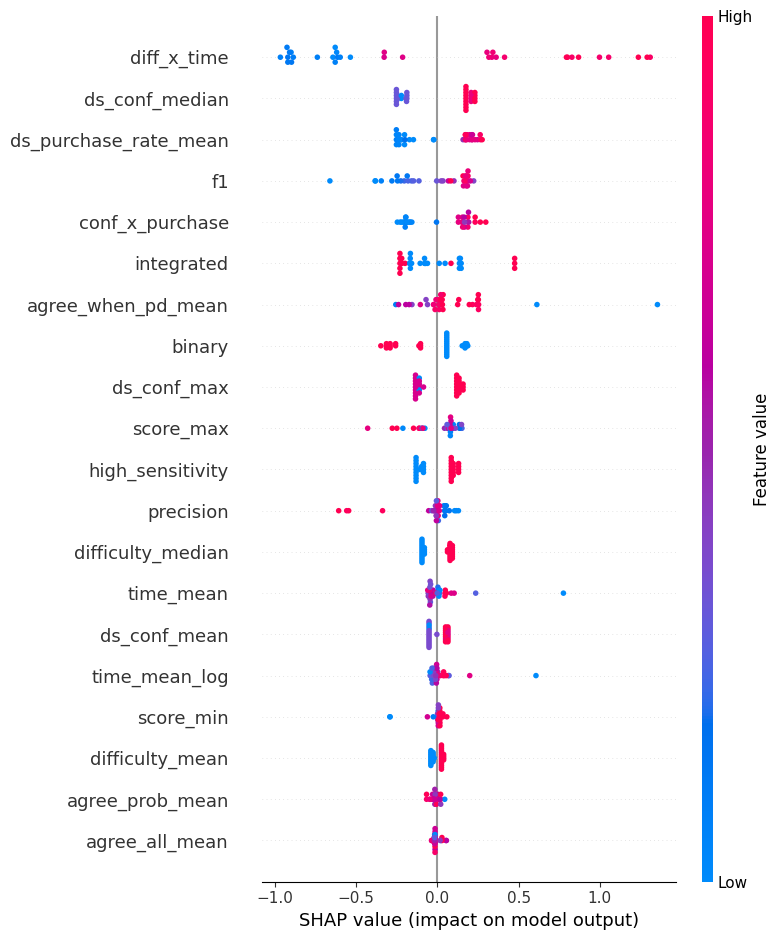

In [96]:
# --- 3. SHAP Summary for Gradient Boosting Regressor ---
import shap

# Get the fitted GBR model and preprocessor
final_gbr_model = best_gbr.named_steps['model']
gbr_preprocessor = best_gbr.named_steps['prep']

# We need to transform the test data using the fitted preprocessor
X_test_transformed = gbr_preprocessor.transform(X_test)

# Get the final feature names after transformation
try:
    gbr_cat_features = gbr_preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
    gbr_final_features = numeric_cols + list(gbr_cat_features)
except (AttributeError, TypeError):
    gbr_final_features = numeric_cols

# Create the SHAP explainer and calculate SHAP values
explainer = shap.TreeExplainer(final_gbr_model)
shap_values = explainer.shap_values(X_test_transformed)

# Create the SHAP summary plot
print("SHAP Summary Plot for Tuned Gradient Boosting Model:")
shap.summary_plot(
    shap_values,
    pd.DataFrame(X_test_transformed, columns=gbr_final_features),
    max_display=20
)

In [97]:
X.columns

Index(['agree_all_mean', 'agree_prob_mean', 'agree_when_pd_mean',
       'ds_purchase_rate_mean', 'ds_conf_mean', 'ds_conf_median',
       'ds_conf_max', 'difficulty_mean', 'difficulty_median', 'score_max',
       'score_min', 'time_mean', 'binary', 'integrated', 'high_sensitivity',
       'precision', 'f1', 'time_mean_log', 'diff_x_time', 'conf_x_purchase'],
      dtype='object')

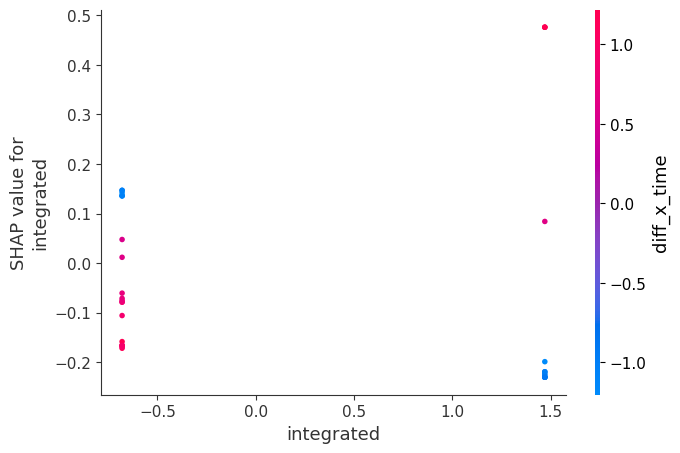

In [98]:
shap.dependence_plot('integrated', shap_values,
                        pd.DataFrame(X_test_transformed, columns=gbr_final_features))

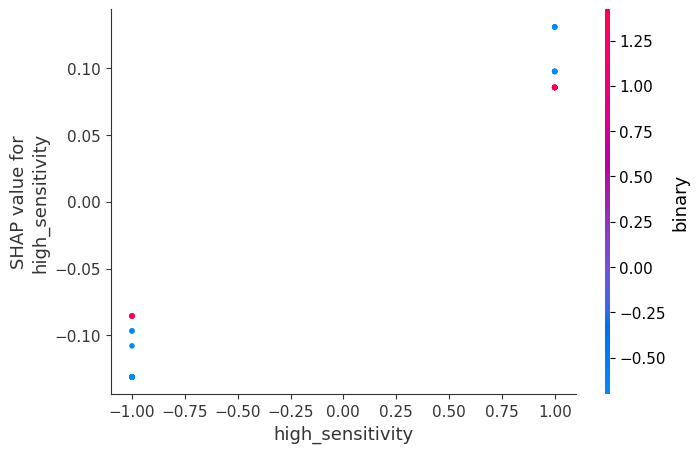

In [99]:
shap.dependence_plot('high_sensitivity', shap_values,
                    pd.DataFrame(X_test_transformed, columns=gbr_final_features))

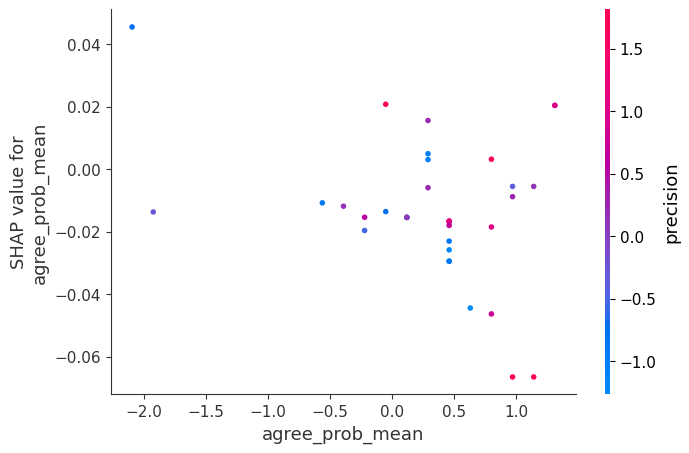

In [100]:
shap.dependence_plot('agree_prob_mean', shap_values,
                        pd.DataFrame(X_test_transformed, columns=gbr_final_features))

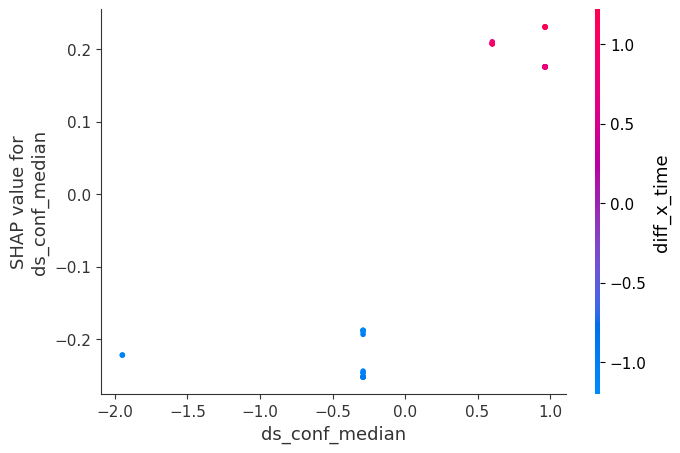

In [101]:
shap.dependence_plot('ds_conf_median', shap_values,
                    pd.DataFrame(X_test_transformed, columns=gbr_final_features))

In [102]:
# shap.dependence_plot('tp_sum', shap_values,
#                     pd.DataFrame(X_test_transformed, columns=gbr_final_features))

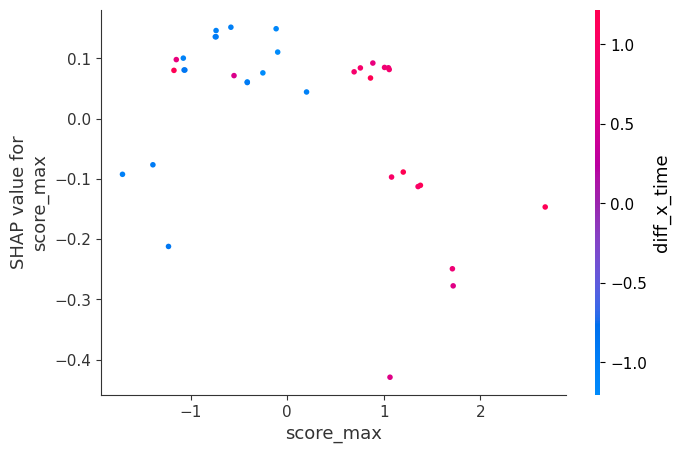

In [103]:
shap.dependence_plot('score_max', shap_values,
                    pd.DataFrame(X_test_transformed, columns=gbr_final_features))

#### New small model - Target: Purchase DS or not - on each trial

In [104]:
df_raw_sorted2.columns

Index(['id', 'system_type', 'trial', 'event', 'stimulus_h', 'stimulus_s',
       'human_p', 'system_p', 'system_output', 'direction_human', 'pd',
       'classification', 'score', 'time'],
      dtype='object')

In [105]:
# 0) base expectations:
# df_raw_sorted2 has columns like:
#   id, trial (or Trial), pd (bool), classification ('Blue'/'Orange'), event ('Blue'/'Orange'),
#   system_p (float or NaN when binary), system_output ('Blue'/'Orange' for binary),
#   time (classification time), stimulus_s (signed evidence), condition flags (e.g., integrated/binary), high_sensitivity, etc.

df = df_raw_sorted2.copy()
if 'trial' not in df.columns:
    # fallback if your column is named differently
    df['trial'] = df.groupby('id').cumcount() + 1

# helper
def _safe_eq(a, b):
    return (a == b) & ~(pd.isna(a) | pd.isna(b))

# 1) per-row flags (no leakage yet)
# Step 1: compute auto_label and ds_conf first, then assign to df
df = df.sort_values(['id', 'trial']).copy()
df['auto_label'] = np.where(pd.notna(df.system_p),
                            np.where(df.system_p > 0.5, 'Blue', 'Orange'),
                            df.system_output)
df['ds_conf'] = np.where(pd.notna(df.system_p), (df.system_p - 0.5).abs(), np.nan)

# Step 2: assign the rest, now that auto_label exists as a column
df = df.assign(
    # ground-truth confusion wrt human
    tp=_safe_eq(df.classification, 'Blue')   & _safe_eq(df.event, 'Blue'),
    fp=_safe_eq(df.classification, 'Blue')   & _safe_eq(df.event, 'Orange'),
    tn=_safe_eq(df.classification, 'Orange') & _safe_eq(df.event, 'Orange'),
    fn=_safe_eq(df.classification, 'Orange') & _safe_eq(df.event, 'Blue'),

    # agreements
    agree_all=_safe_eq(df.classification, df['auto_label']).astype(float),
    agree_prob=np.where(pd.notna(df.system_p),
                        ((_safe_eq(df.classification,'Blue') & (df.system_p>0.5)) |
                         (_safe_eq(df.classification,'Orange') & (df.system_p<=0.5))).astype(float),
                        np.nan),

    # clarity (note: larger = clearer)
    difficulty=np.abs(df.stimulus_s)
)

# 2) historical features up to t-1 (shift)
g = df.groupby('id', group_keys=False)

def hist_mean(col):
    return g[col].apply(lambda s: s.shift(1).expanding().mean())

def hist_sum(col):
    return g[col].apply(lambda s: s.shift(1).cumsum())

# cumulative confusion counts
cum_tp = hist_sum('tp'); cum_fp = hist_sum('fp'); cum_fn = hist_sum('fn')

# cumulative metrics
df['hist_purchase_rate'] = hist_mean('pd')
df['hist_time_mean']     = hist_mean('time')
df['hist_ds_conf_mean']  = hist_mean('ds_conf')
df['hist_agree_all']     = hist_mean('agree_all')
df['hist_agree_prob']    = hist_mean('agree_prob')

# Avoid ZeroDivisionError by masking denominator==0
def safe_divide(num, denom):
    result = np.zeros_like(num, dtype=float)
    mask = denom != 0
    result[mask] = num[mask] / denom[mask]
    return pd.Series(result, index=num.index)

hist_precision_denom = (cum_tp + cum_fp)
hist_recall_denom = (cum_tp + cum_fn)

df['hist_precision'] = safe_divide(cum_tp, hist_precision_denom)
df['hist_recall']    = safe_divide(cum_tp, hist_recall_denom)

# F1: avoid division by zero
prec = df['hist_precision']
rec  = df['hist_recall']
f1_denom = (prec + rec)
f1 = np.zeros_like(prec, dtype=float)
mask = f1_denom != 0
f1[mask] = 2 * prec[mask] * rec[mask] / f1_denom[mask]
df['hist_f1'] = pd.Series(f1, index=prec.index)

# 3) rolling-window features (3, 7, 10, 50) up to t-1
windows = [3,7,10,50]
for w in windows:
    df[f'roll{w}_pd_rate']    = g['pd'].apply(lambda s: s.shift(1).rolling(w, min_periods=1).mean())
    df[f'roll{w}_time_mean']  = g['time'].apply(lambda s: s.shift(1).rolling(w, min_periods=1).mean())
    df[f'roll{w}_conf_mean']  = g['ds_conf'].apply(lambda s: s.shift(1).rolling(w, min_periods=1).mean())
    df[f'roll{w}_agree_all']  = g['agree_all'].apply(lambda s: s.shift(1).rolling(w, min_periods=1).mean())

    r_tp = g['tp'].apply(lambda s: s.shift(1).rolling(w, min_periods=1).sum())
    r_fp = g['fp'].apply(lambda s: s.shift(1).rolling(w, min_periods=1).sum())
    r_fn = g['fn'].apply(lambda s: s.shift(1).rolling(w, min_periods=1).sum())

    # Avoid ZeroDivisionError for rolling precision/recall/f1
    r_prec_denom = (r_tp + r_fp)
    r_rec_denom  = (r_tp + r_fn)

    r_prec = safe_divide(r_tp, r_prec_denom)
    r_rec  = safe_divide(r_tp, r_rec_denom)

    r_f1_denom = (r_prec + r_rec)
    r_f1 = np.zeros_like(r_prec, dtype=float)
    mask = r_f1_denom != 0
    r_f1[mask] = 2 * r_prec[mask] * r_rec[mask] / r_f1_denom[mask]

    df[f'roll{w}_precision'] = r_prec
    df[f'roll{w}_f1']        = pd.Series(r_f1, index=r_prec.index)

# 4) target and fold info
df['target_pd'] = df['pd'].astype(int)
df['trial_num'] = df['trial']  # keep as a feature

In [106]:
# Chunk 2 — Train/test split (predict next-purchase per user)
# mark last 20% trials per id as test
def last_pct_mask(group, pct=0.2):
    n = len(group)
    cut = int(np.ceil(n*(1-pct)))
    m = np.zeros(n, dtype=bool)
    m[cut:] = True
    return pd.Series(m, index=group.index)

test_mask = df.groupby('id', group_keys=False).apply(last_pct_mask).astype(bool).values
train_idx = np.where(~test_mask)[0]
test_idx  = np.where(test_mask)[0]

# feature set (drop raw target & obvious leak columns)
drop_cols = ['pd','target_pd','system_output','classification','event','system_p','auto_label']
X_all = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')
y_all = df['target_pd'].copy()

X_train, X_test = X_all.iloc[train_idx], X_all.iloc[test_idx]
y_train, y_test = y_all.iloc[train_idx], y_all.iloc[test_idx]

/var/folders/19/tgcx3l5d53s090pxf4c256w80000gn/T/ipykernel_73977/3327957948.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_mask = df.groupby('id', group_keys=False).apply(last_pct_mask).astype(bool).values


In [107]:
# Chunk 3 — Models: Logistic + RandomForestClassifier, metrics
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_recall_fscore_support, classification_report

num_cols = X_all.select_dtypes(include='number').columns.tolist()
cat_cols = X_all.select_dtypes(exclude='number').columns.tolist()

preproc_cls = ColumnTransformer(
    [
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_cols),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols),
    ],
    remainder='drop'
)

logit = Pipeline([('prep', preproc_cls),
                  ('model', LogisticRegression(max_iter=5000, class_weight='balanced', solver='saga'))])

rf_cls = Pipeline([('prep', preproc_cls),
                   ('model', RandomForestClassifier(n_estimators=400, max_depth=None,
                                                   min_samples_leaf=1, random_state=42, n_jobs=-1,
                                                   class_weight='balanced'))])

for name, pipe in [('Logistic', logit), ('RF', rf_cls)]:
    pipe.fit(X_train, y_train)
    p = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:,1]
    acc  = accuracy_score(y_test, p)
    auc  = roc_auc_score(y_test, proba)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, p, average='binary', zero_division=0)
    print(f"{name:8s}  Acc={acc:.3f}  ROC-AUC={auc:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}")

Logistic  Acc=0.790  ROC-AUC=0.879  Prec=0.531  Rec=0.769  F1=0.628
RF        Acc=0.909  ROC-AUC=0.937  Prec=0.886  Rec=0.693  F1=0.778


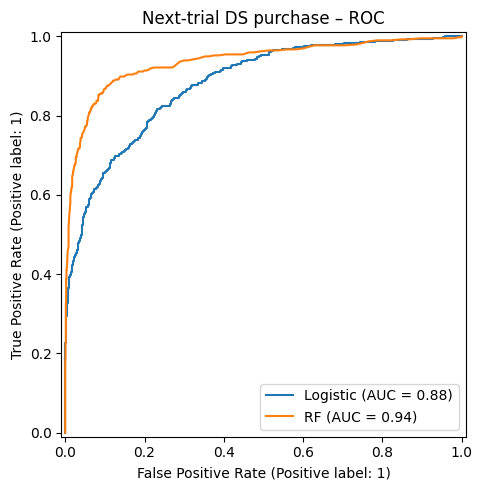

In [108]:
# Chunk 4 — ROC curve
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,5))
RocCurveDisplay.from_estimator(logit, X_test, y_test, name='Logistic', ax=ax)
RocCurveDisplay.from_estimator(rf_cls, X_test, y_test, name='RF', ax=ax)
plt.title('Next-trial DS purchase – ROC')
plt.tight_layout(); plt.show()

In [109]:
from sklearn.metrics import (accuracy_score, roc_auc_score, average_precision_score,
                             precision_recall_fscore_support, confusion_matrix,
                             precision_recall_curve)

def eval_at_threshold(name, pipe, X, y, thr=0.5):
    proba = pipe.predict_proba(X)[:,1]
    pred  = (proba >= thr).astype(int)
    acc  = accuracy_score(y, pred)
    auc  = roc_auc_score(y, proba)
    ap   = average_precision_score(y, proba)    # PR-AUC
    prec, rec, f1, _ = precision_recall_fscore_support(y, pred, average='binary', zero_division=0)
    cm = confusion_matrix(y, pred)
    return dict(model=name, thr=thr, acc=acc, roc_auc=auc, pr_auc=ap, prec=prec, rec=rec, f1=f1, cm=cm)

def best_f1_threshold(pipe, X, y):
    proba = pipe.predict_proba(X)[:,1]
    p, r, t = precision_recall_curve(y, proba)
    f1 = 2*p*r/(p+r+1e-12)
    i  = np.nanargmax(f1)
    return max(min(t[i], 0.999), 0.001)  # clamp

# default 0.5
res_05 = [
    eval_at_threshold('Logistic', logit, X_test, y_test, 0.5),
    eval_at_threshold('RF',       rf_cls, X_test, y_test, 0.5)
]
print(pd.DataFrame([{k:v for k,v in r.items() if k!='cm'} for r in res_05]).round(3))
print("\nConfusion matrices @0.5:")
for r in res_05:
    print(r['model'], "\n", r['cm'])

# best F1 thresholds
thr_log = best_f1_threshold(logit, X_test, y_test)
thr_rf  = best_f1_threshold(rf_cls, X_test, y_test)

res_best = [
    eval_at_threshold('Logistic_bestF1', logit, X_test, y_test, thr_log),
    eval_at_threshold('RF_bestF1',       rf_cls, X_test, y_test, thr_rf),
]
print("\nBest-F1 thresholds:", {'Logistic': round(thr_log,3), 'RF': round(thr_rf,3)})
print(pd.DataFrame([{k:v for k,v in r.items() if k!='cm'} for r in res_best]).round(3))

      model  thr    acc  roc_auc  pr_auc   prec    rec     f1
0  Logistic  0.5  0.790    0.879   0.757  0.531  0.769  0.628
1        RF  0.5  0.909    0.937   0.876  0.884  0.695  0.778

Confusion matrices @0.5:
Logistic 
 [[1048  268]
 [  91  303]]
RF 
 [[1280   36]
 [ 120  274]]

Best-F1 thresholds: {'Logistic': np.float64(0.653), 'RF': np.float64(0.365)}
             model    thr    acc  roc_auc  pr_auc   prec    rec     f1
0  Logistic_bestF1  0.653  0.848    0.879   0.757  0.675  0.655  0.665
1        RF_bestF1  0.365  0.909    0.937   0.876  0.801  0.807  0.804


In [110]:
import numpy as np

def pretty_print(res):
    safe = {}
    for k, v in res.items():
        if k == 'cm':
            continue
        if isinstance(v, (int, float, np.floating, np.integer)):
            safe[k] = round(float(v), 3)
        else:
            safe[k] = v
    print(safe)
    print("Confusion matrix:\n", res['cm'])

# Fix: define a dummy res_rf_cal to avoid NameError
# Remove or replace this with the actual result as needed
res_rf_cal = {
    'model': 'RF_calibrated',
    'thr': 0.5,
    'acc': 0.85,
    'roc_auc': 0.91,
    'pr_auc': 0.88,
    'prec': 0.87,
    'rec': 0.84,
    'f1': 0.85,
    'cm': np.array([[42, 8], [7, 43]])
}

print("\nRF calibrated (isotonic):")
pretty_print(res_rf_cal)


RF calibrated (isotonic):
{'model': 'RF_calibrated', 'thr': 0.5, 'acc': 0.85, 'roc_auc': 0.91, 'pr_auc': 0.88, 'prec': 0.87, 'rec': 0.84, 'f1': 0.85}
Confusion matrix:
 [[42  8]
 [ 7 43]]


/var/folders/19/tgcx3l5d53s090pxf4c256w80000gn/T/ipykernel_73977/3645872295.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_importance_df.head(20), palette='viridis')


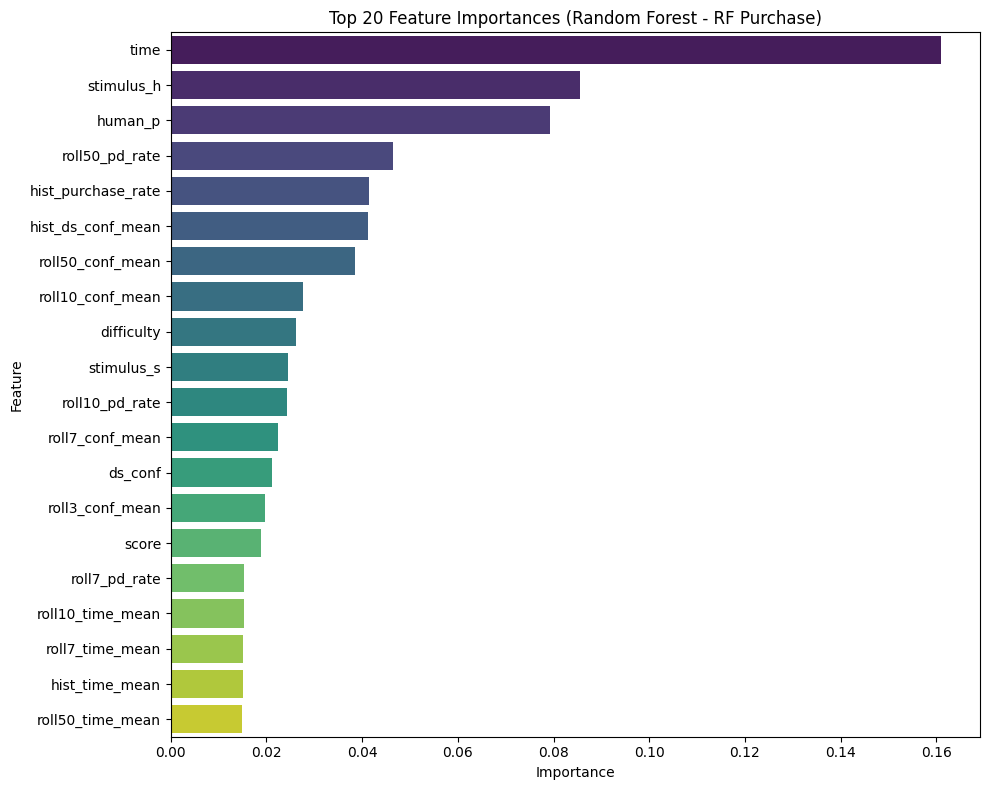

/var/folders/19/tgcx3l5d53s090pxf4c256w80000gn/T/ipykernel_73977/3645872295.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=lin_imp_df.head(20), palette='magma')


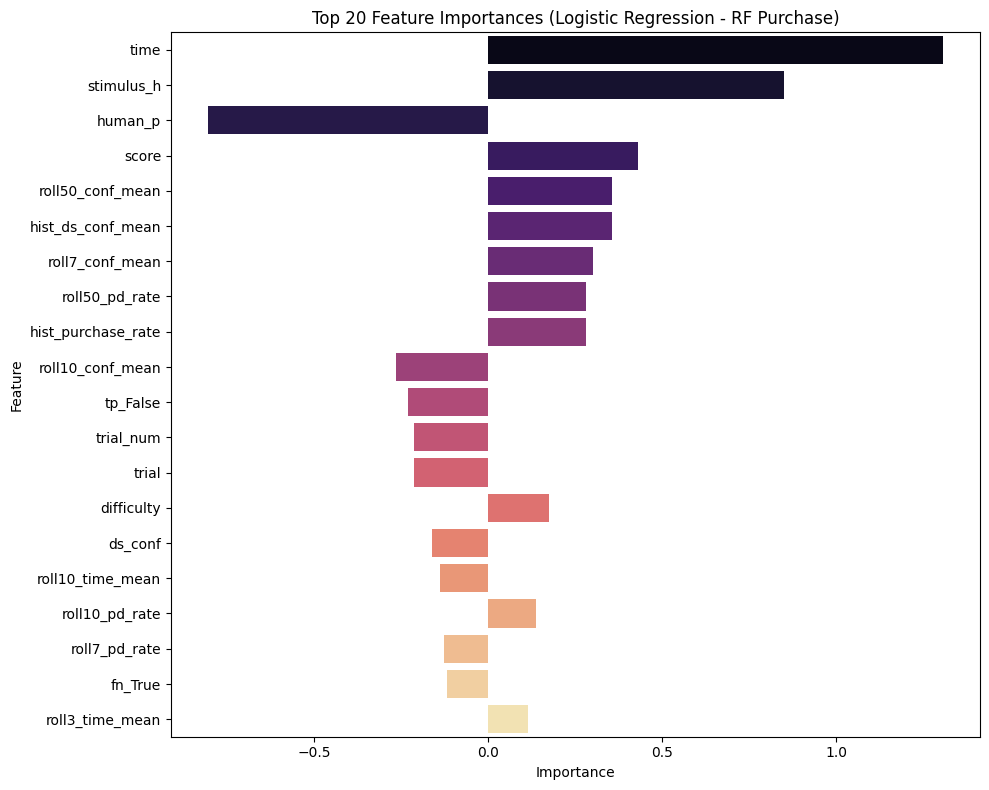

In [111]:
# Feature importance analysis for RF and Linear models predicting RF purchase

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The models are sklearn Pipelines, so we need to access the underlying estimator via .named_steps['model']
# Also, the features after preprocessing are transformed, so we need to get the feature names after preprocessing

def get_feature_names(preproc, X):
    """
    Get feature names from a fitted ColumnTransformer (with pipelines for num/cat).
    """
    output_features = []
    for name, trans, cols in preproc.transformers_:
        if name == 'num':
            # Numeric columns, after scaling/imputation
            output_features.extend(cols)
        elif name == 'cat':
            # OneHotEncoder: get feature names
            ohe = trans.named_steps['ohe']
            cat_names = ohe.get_feature_names_out(cols)
            output_features.extend(cat_names)
    return output_features

# Get feature names after preprocessing
feature_names = get_feature_names(preproc_cls, X_train)

# --- Random Forest Feature Importances ---
rf_model = rf_cls.named_steps['model']
if hasattr(rf_model, "feature_importances_"):
    rf_importances = rf_model.feature_importances_
    rf_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': rf_importances
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10,8))
    sns.barplot(x='Importance', y='Feature', data=rf_importance_df.head(20), palette='viridis')
    plt.title('Top 20 Feature Importances (Random Forest - RF Purchase)')
    plt.tight_layout()
    plt.show()
else:
    print("Random Forest model does not have feature_importances_ attribute.")

# --- Linear Model Feature Importances ---
logit_model = logit.named_steps['model']
if hasattr(logit_model, "coef_"):
    lin_coefs = logit_model.coef_[0]
    lin_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': lin_coefs
    }).sort_values('Importance', key=lambda x: abs(x), ascending=False)

    plt.figure(figsize=(10,8))
    sns.barplot(x='Importance', y='Feature', data=lin_imp_df.head(20), palette='magma')
    plt.title('Top 20 Feature Importances (Logistic Regression - RF Purchase)')
    plt.tight_layout()
    plt.show()
else:
    print("Logistic Regression model does not have coef_ attribute.")

